## 0.Import Dependencies

In [111]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

## 1.Load .xlsx files and Create File Inventory


In [112]:
RAW_DIR = Path(r"E:/Water Quality Research/Data/tabular_data_14/01_raw")
files = sorted(p for p in RAW_DIR.glob("*.xlsx") if not p.name.startswith("~$"))
OUT_DIR = Path(r"E:\Water Quality Research\Data\tabular_data_14\02_intermediate")
OUT_DIR.mkdir(parents=True, exist_ok=True)

YEARS = [2562,2563,2564, 2565, 2566, 2567, 2568]

files = sorted(p for p in RAW_DIR.glob("*.xlsx") if not p.name.startswith("~$"))

file_table = pd.DataFrame({
    "path": files,
    "filename": [p.name for p in files],
})

file_table["year_be"] = file_table["filename"].str.extract(r"(25\d{2})").astype(int)
file_table = file_table[file_table["year_be"].isin(YEARS)]

file_table

,path,filename,year_be
0,E:\Water Quality Research\Data\tabular_data_14...,wq_data_2562.xlsx,2562
1,E:\Water Quality Research\Data\tabular_data_14...,wq_data_2563.xlsx,2563
2,E:\Water Quality Research\Data\tabular_data_14...,wq_data_2564.xlsx,2564
3,E:\Water Quality Research\Data\tabular_data_14...,wq_data_2565.xlsx,2565
4,E:\Water Quality Research\Data\tabular_data_14...,wq_data_2566.xlsx,2566
5,E:\Water Quality Research\Data\tabular_data_14...,wq_data_2567.xlsx,2567
6,E:\Water Quality Research\Data\tabular_data_14...,wq_data_2568.xlsx,2568


## 2.Config and Helper functions

In [113]:
def list_sheets(path):
    xls = pd.ExcelFile(path)
    return xls.sheet_names

def pick_sheet(path):
    sheets = list_sheets(path)

    combined = [
        s for s in sheets if "รวม" in s or s.strip().startswith("1-4")
    ]

    if combined:
        return combined[-1]
    
    return sheets[-1]

TARGETS = [
    "DO_mg_l",
    "BOD_mg_l",
    "turbidity_NTU",
    "SS_mg_l",
    "TCB_MPN_100ml",
    "FCB_MPN_100ml",
    "NH3_N_mg_l",
    "WQI",
]

ID = [
    "year_be", "station", "survey_date", "survey_no",
    "water_body", "source_file", "source_sheet"
]

COLUMN_ALIASES = {
    "water_body": ["แม่น้ำ", "basin"],
    "survey_no": ["ครั้งที่", "surveyNo"],
    "station": ["Station", "station"],
    "survey_date": ["Date", "surveyDate"],
    "survey_time": ["Time", "surveyTime"],

    "depth_m": ["Depth(m)"],
    "temp_air": ["Temp(a)"],
    "temp_water": ["Temp(w)"],
    "pH": ["pH"],

    "turbidity_NTU": ["tur(NTU)", "turbid"],
    "conductivity": ["Cond(µS)", "Cond(mS)", "conductivity"],
    "salinity_ppt": ["Sal(ppt)", "salty"],

    "DO_mg_l": ["DO(mg/l)"],
    "BOD_mg_l": ["BOD(mg/l)"],
    "TCB_MPN_100ml": ["Total Coli(MPN/100ml)", "Total Coli"],
    "FCB_MPN_100ml": ["Fecal Coli(MPN/100ml)", "Fecal Coli"],

    "TP_mg_l": ["TP(mg/l)"],
    "NO3_N_mg_l": ["NO3-N(mg/l)"],
    "NO2_N_mg_l": ["NO2-N(mg/l)"],
    "NH3_N_mg_l": ["NH3-N(mg/l)"],
    "SS_mg_l": ["SS(mg/l)"],
    "TS_mg_l": ["TS(mg/l)"],
    "TDS_mg_l": ["TDS(mg/l)"],
    "WQI": ["WQI", "wqi"],
}

QC_MEASURE_COLS = [
    "depth_m", "temp_air", "temp_water", "pH",
    "turbidity_NTU", "conductivity", "salinity_ppt",
    "DO_mg_l", "BOD_mg_l", "TCB_MPN_100ml", "FCB_MPN_100ml",
    "TP_mg_l", "NO3_N_mg_l", "NO2_N_mg_l", "NH3_N_mg_l",
    "SS_mg_l", "TS_mg_l", "TDS_mg_l", "WQI",
]


## 3.Read and Normalize files

In [114]:
def normalize_columns(df):
    out = pd.DataFrame()

    for canonical, aliases in COLUMN_ALIASES.items():
        found = None
        for col in aliases:
            if col in df.columns:
                found = col
                break

        out[canonical] = df[found] if found else np.nan

    return out


def read_one_file(path, year_be):
    sheet = pick_sheet(path)
    raw = pd.read_excel(path, sheet_name=sheet)

    df = normalize_columns(raw)
    df["source_file"] = path.name
    df["source_sheet"] = sheet
    df["year_be"] = year_be
    df["year_ad"] = year_be - 543

    return df

## 4.Create basic QC

In [115]:
frames = []

for _, row in file_table.iterrows():
    df_year = read_one_file(row["path"], row["year_be"])
    frames.append(df_year)

master = pd.concat(frames, ignore_index=True)

master.shape, master.head()

((867, 28),
   water_body survey_no station          survey_date survey_time depth_m  \
 0    หลังสวน     3//62    LS01  2019-07-22 00:00:00    12:15:00     2.6   
 1    หลังสวน     3//62    LS02  2019-07-22 00:00:00    11:40:00     1.5   
 2    หลังสวน     3//62    LS03  2019-07-22 00:00:00    11:10:00     1.6   
 3    หลังสวน     3//62    LS04  2019-07-22 00:00:00    10:30:00     1.9   
 4   ท่าตะเภา     3//62    CP01  2019-07-23 00:00:00    12:20:00     3.4   
 
   temp_air temp_water   pH turbidity_NTU  ... NO2_N_mg_l NH3_N_mg_l SS_mg_l  \
 0     32.8       28.7  7.2           8.0  ...       0.01       0.16      16   
 1     31.5       27.6  7.7           8.0  ...      <0.01       0.08      20   
 2     31.0       27.5  7.9           9.0  ...      <0.01       0.12      34   
 3     31.0       28.1  8.7          12.0  ...      <0.01       0.13      23   
 4     37.5       30.6  7.2           9.0  ...       0.02       0.39      12   
 
   TS_mg_l TDS_mg_l WQI        source_file      

In [116]:
master.info()

<class 'pandas.DataFrame'>
RangeIndex: 867 entries, 0 to 866
Data columns (total 28 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   water_body     867 non-null    str   
 1   survey_no      867 non-null    str   
 2   station        867 non-null    str   
 3   survey_date    867 non-null    object
 4   survey_time    867 non-null    object
 5   depth_m        867 non-null    object
 6   temp_air       867 non-null    object
 7   temp_water     867 non-null    object
 8   pH             867 non-null    object
 9   turbidity_NTU  867 non-null    object
 10  conductivity   867 non-null    object
 11  salinity_ppt   867 non-null    object
 12  DO_mg_l        867 non-null    object
 13  BOD_mg_l       867 non-null    object
 14  TCB_MPN_100ml  867 non-null    object
 15  FCB_MPN_100ml  867 non-null    object
 16  TP_mg_l        867 non-null    object
 17  NO3_N_mg_l     867 non-null    object
 18  NO2_N_mg_l     867 non-null    object
 19

In [117]:
print("Columns:", master.columns.tolist())

Columns: ['water_body', 'survey_no', 'station', 'survey_date', 'survey_time', 'depth_m', 'temp_air', 'temp_water', 'pH', 'turbidity_NTU', 'conductivity', 'salinity_ppt', 'DO_mg_l', 'BOD_mg_l', 'TCB_MPN_100ml', 'FCB_MPN_100ml', 'TP_mg_l', 'NO3_N_mg_l', 'NO2_N_mg_l', 'NH3_N_mg_l', 'SS_mg_l', 'TS_mg_l', 'TDS_mg_l', 'WQI', 'source_file', 'source_sheet', 'year_be', 'year_ad']


In [118]:
master.head()

,water_body,survey_no,station,survey_date,survey_time,depth_m,temp_air,temp_water,pH,turbidity_NTU,...,NO2_N_mg_l,NH3_N_mg_l,SS_mg_l,TS_mg_l,TDS_mg_l,WQI,source_file,source_sheet,year_be,year_ad
0,หลังสวน,3//62,LS01,2019-07-22 00:00:00,12:15:00,2.6,32.8,28.7,7.2,8.0,...,0.01,0.16,16,1191,1175.0,-,wq_data_2562.xlsx,รวมน้ำผิวดินครั้งที่ 1-3.2562,2562,2019
1,หลังสวน,3//62,LS02,2019-07-22 00:00:00,11:40:00,1.5,31.5,27.6,7.7,8.0,...,<0.01,0.08,20,76,56.0,-,wq_data_2562.xlsx,รวมน้ำผิวดินครั้งที่ 1-3.2562,2562,2019
2,หลังสวน,3//62,LS03,2019-07-22 00:00:00,11:10:00,1.6,31.0,27.5,7.9,9.0,...,<0.01,0.12,34,81,47.0,-,wq_data_2562.xlsx,รวมน้ำผิวดินครั้งที่ 1-3.2562,2562,2019
3,หลังสวน,3//62,LS04,2019-07-22 00:00:00,10:30:00,1.9,31.0,28.1,8.7,12.0,...,<0.01,0.13,23,61,38.0,-,wq_data_2562.xlsx,รวมน้ำผิวดินครั้งที่ 1-3.2562,2562,2019
4,ท่าตะเภา,3//62,CP01,2019-07-23 00:00:00,12:20:00,3.4,37.5,30.6,7.2,9.0,...,0.02,0.39,12,15780,15768.0,-,wq_data_2562.xlsx,รวมน้ำผิวดินครั้งที่ 1-3.2562,2562,2019


### 4.1 Visual basic QC

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [120]:
def classify_raw_value(x):
    if pd.isna(x):
        return "missing"

    s = str(x).strip()

    if s in ["", "-", "--"]:
        return "dash/missing"
    if s.upper() in ["ND", "N.D."]:
        return "ND"
    if s.startswith("<"):
        return "below_detection"
    if s.startswith(">"):
        return "above_reported"
    
    try:
        float(s.replace(",", ""))
        return "numeric"
    except:
        return "text/unparsed"

#### missing data heatmap

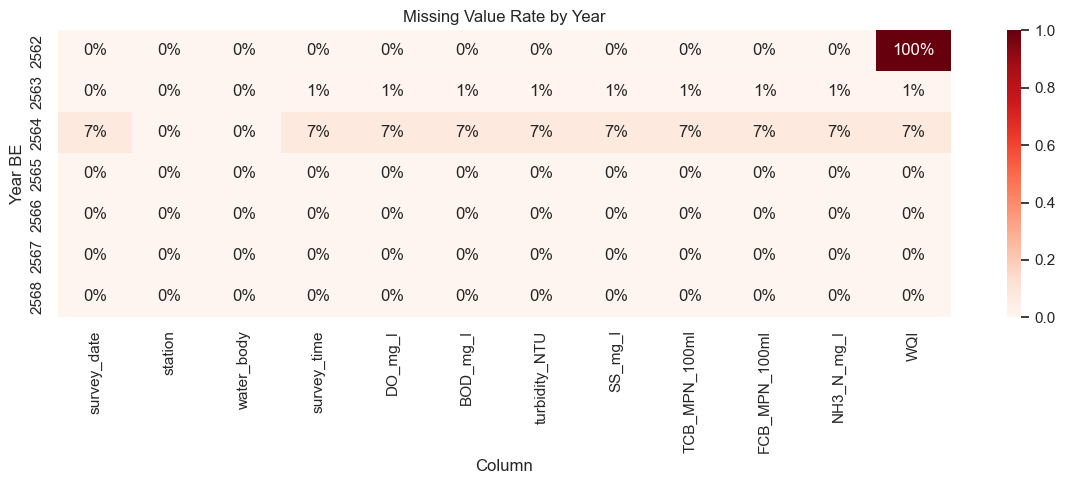

In [121]:
qc_cols = [
    "survey_date", "station", "water_body","survey_time",
    "DO_mg_l", "BOD_mg_l", "turbidity_NTU", "SS_mg_l",
    "TCB_MPN_100ml", "FCB_MPN_100ml", "NH3_N_mg_l", "WQI",
]

missing_like_by_year = (
    master
    .groupby("year_be")[qc_cols]
    .apply(
        lambda df: df.apply(
            lambda col: col.map(classify_raw_value).isin(["missing", "dash/missing"]).mean()
        )
    )
)

plt.figure(figsize=(12, 5))
sns.heatmap(missing_like_by_year, annot=True, fmt=".0%", cmap="Reds", cbar=True)
plt.title("Missing Value Rate by Year")
plt.ylabel("Year BE")
plt.xlabel("Column")
plt.tight_layout()
plt.show()

In [122]:
target_cols = [
    "DO_mg_l", "BOD_mg_l", "turbidity_NTU", "SS_mg_l",
    "TCB_MPN_100ml", "FCB_MPN_100ml", "NH3_N_mg_l", "WQI",
]

qc_long = []

for col in target_cols:
    temp = master[["year_be", col]].copy()
    temp["parameter"] = col
    temp["value_type"] = temp[col].apply(classify_raw_value)
    qc_long.append(temp[["year_be", "parameter", "value_type"]])

qc_long = pd.concat(qc_long, ignore_index=True)

qc_counts = (
    qc_long
    .groupby(["year_be", "parameter", "value_type"])
    .size()
    .reset_index(name="count")
)

### barplot anormaly value in earch targets by year

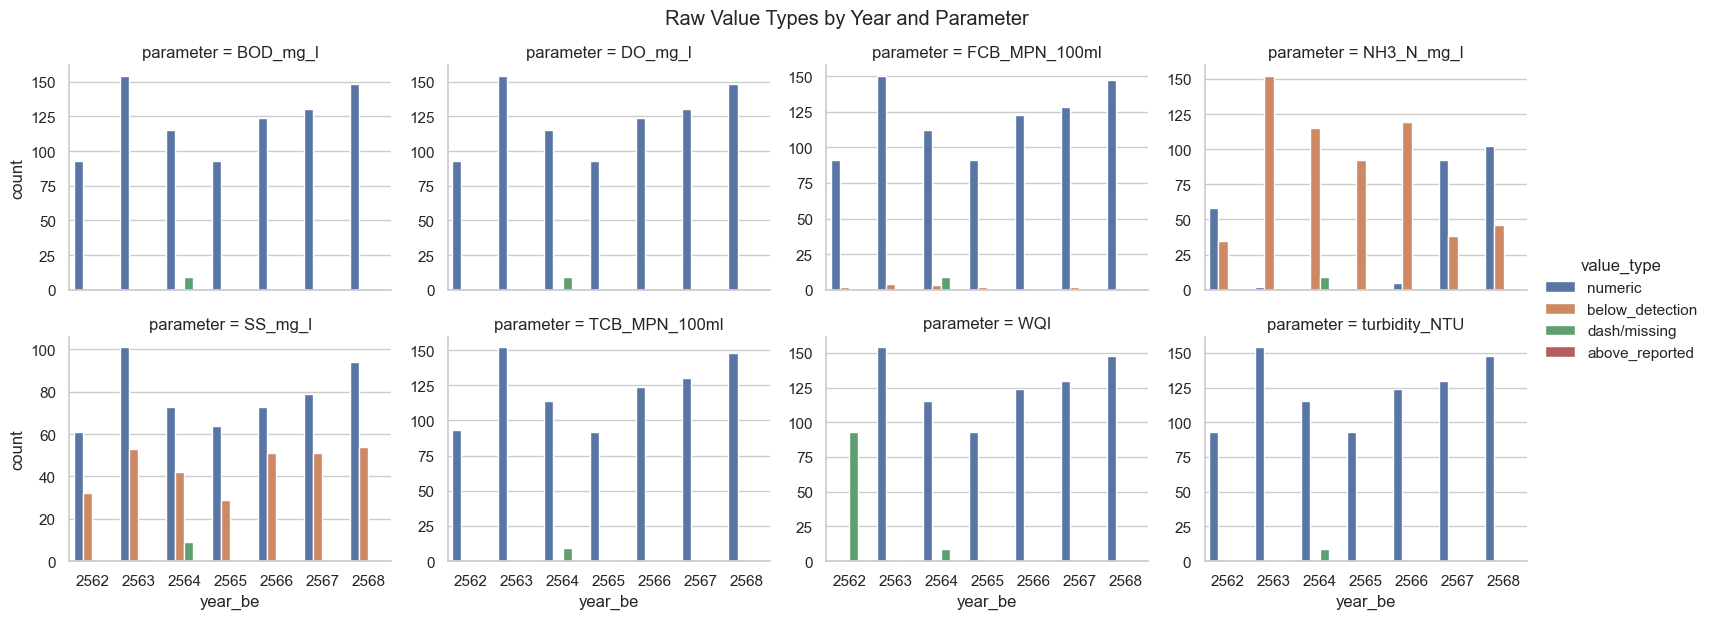

In [123]:
g = sns.catplot(
    data=qc_counts,
    x="year_be",
    y="count",
    hue="value_type",
    col="parameter",
    col_wrap=4,
    kind="bar",
    height=3,
    aspect=1.3,
    sharey=False
)

g.fig.suptitle("Raw Value Types by Year and Parameter", y=1.03)
plt.show()

In [124]:
inspect_long = master[ID + target_cols].melt(
    id_vars=ID,
    value_vars=target_cols,
    var_name="parameter",
    value_name="raw_value",
)

inspect_long["value_type"] = inspect_long["raw_value"].apply(classify_raw_value)

problem_values = inspect_long[
    inspect_long["value_type"].isin([
        "missing",
        "dash/missing",
        "below_detection",
        "ND",
        "above_reported",
        "text/unparsed",
    ])
].copy()

problem_values.sort_values(
    ["year_be", "parameter", "station", "survey_date"]
).head(100)

,year_be,station,survey_date,survey_no,water_body,source_file,source_sheet,parameter,raw_value,value_type
4417,2562,TP07,2019-02-14 00:00:00,1//62,ตาปี,wq_data_2562.xlsx,รวมน้ำผิวดินครั้งที่ 1-3.2562,FCB_MPN_100ml,<18,below_detection
4355,2562,TP07,2019-08-05 00:00:00,3//62,ตาปี,wq_data_2562.xlsx,รวมน้ำผิวดินครั้งที่ 1-3.2562,FCB_MPN_100ml,<18,below_detection
5268,2562,CP01,2019-02-05 00:00:00,1//62,ท่าตะเภา,wq_data_2562.xlsx,รวมน้ำผิวดินครั้งที่ 1-3.2562,NH3_N_mg_l,<0.10,below_detection
5237,2562,CP01,2019-05-08 00:00:00,2//62,ท่าตะเภา,wq_data_2562.xlsx,รวมน้ำผิวดินครั้งที่ 1-3.2562,NH3_N_mg_l,<0.10,below_detection
5270,2562,CP03,2019-02-05 00:00:00,1//62,ท่าตะเภา,wq_data_2562.xlsx,รวมน้ำผิวดินครั้งที่ 1-3.2562,NH3_N_mg_l,<0.10,below_detection
...,...,...,...,...,...,...,...,...,...,...
6077,2562,PN02,2019-07-31 00:00:00,3//62,ปากพนัง,wq_data_2562.xlsx,รวมน้ำผิวดินครั้งที่ 1-3.2562,WQI,-,dash/missing
6140,2562,PN04,2019-02-12 00:00:00,1//62,ปากพนัง,wq_data_2562.xlsx,รวมน้ำผิวดินครั้งที่ 1-3.2562,WQI,-,dash/missing
6109,2562,PN04,2019-05-14 00:00:00,2//62,ปากพนัง,wq_data_2562.xlsx,รวมน้ำผิวดินครั้งที่ 1-3.2562,WQI,-,dash/missing
6078,2562,PN04,2019-07-31 00:00:00,3//62,ปากพนัง,wq_data_2562.xlsx,รวมน้ำผิวดินครั้งที่ 1-3.2562,WQI,-,dash/missing


In [125]:
def normalize_survey_date_to_ad(series):
    dates = pd.to_datetime(series, errors="coerce")
    be_mask = dates.notna() & (dates.dt.year >= 2400)
    dates.loc[be_mask] = dates.loc[be_mask] - pd.DateOffset(years=543)
    return dates

measure_missing_all = master[QC_MEASURE_COLS].apply(
    lambda col: col.map(classify_raw_value).isin(["missing", "dash/missing"])
).all(axis=1)

master["survey_date"] = normalize_survey_date_to_ad(master["survey_date"])
date_missing = master["survey_date"].isna()

master["row_qc_status"] = "ok"
master.loc[measure_missing_all, "row_qc_status"] = "no_measurement_values"
master.loc[date_missing, "row_qc_status"] = "missing_date"
master.loc[measure_missing_all & date_missing, "row_qc_status"] = "missing_date_and_measurements"

# Keep exported dates as AD ISO strings for Earth Engine and other satellite APIs.
master["survey_date"] = master["survey_date"].dt.strftime("%Y-%m-%d")

master["row_qc_status"].value_counts()


row_qc_status
ok                               856
missing_date_and_measurements      9
missing_date                       1
no_measurement_values              1
Name: count, dtype: int64

In [126]:
master = master[master["row_qc_status"] == "ok"].copy()

In [127]:
def parse_censored_value(x):
    value_type = classify_raw_value(x)

    if value_type in ["missing", "dash/missing", "ND", "text/unparsed"]:
        return np.nan, value_type, np.nan

    s = str(x).strip()

    if value_type == "below_detection":
        dl = float(s.replace("<", "").replace(",", "").strip())
        return dl / np.sqrt(2), "below_detection", dl

    if value_type == "above_reported":
        val = float(s.replace(">", "").replace(",", "").strip())
        return val, "above_reported", val

    return float(s.replace(",", "")), None, np.nan

In [128]:
for col in QC_MEASURE_COLS:
    parsed = master[col].apply(parse_censored_value)

    master[f"{col}_clean"] = parsed.apply(lambda t: t[0])
    master[f"{col}_value_type"] = parsed.apply(lambda t: t[1])
    master[f"{col}_detection_limit"] = parsed.apply(lambda t: t[2])

### 4.3 Recalculate missing WQI using PCD/MNRE WQI-new method

Year 2562 has no reported `WQI` values in the raw Excel files, but it has complete inputs for the five PCD WQI-new parameters: `DO`, `BOD`, `TCB`, `FCB`, and `NH3-N`. This notebook therefore computes `WQI_recalc_pcd5` for audit and fills `WQI_clean` only where the original reported WQI is missing.

Method used here:

1. Convert `DO`, `BOD`, `TCB`, `FCB`, and `NH3-N` to 0-100 subindex scores using the PCD WQI-new equations.
2. Compute `WQI_mean_subindex_pcd5` as the mean of the five subindex scores.
3. Compute `A`, the quality level of the five-score mean, using four adjustment levels: `good`, `fair`, `degraded`, and `very_degraded`.
4. Compute `B`, the worst quality level among the five parameter subindex scores.
5. Compute `WQI_adjustment_pcd5` from the level gap between `A` and `B`: gap 0, 1, 2, or 3 maps to adjustment 0, 10, 15, or 20.
6. Compute `WQI_recalc_pcd5 = WQI_mean_subindex_pcd5 - WQI_adjustment_pcd5`.

Important audit columns:

- `WQI_reported`: original parsed WQI before filling missing values.
- `WQI_recalc_pcd5`: WQI recalculated from the five PCD WQI-new parameters.
- `WQI_clean`: final WQI used downstream; reported values are kept, missing values are filled from `WQI_recalc_pcd5`.
- `WQI_source`: whether final WQI came from `reported`, `recalculated_pcd5`, or `missing_not_recalculated`.
- `WQI_recalc_status`: whether the row had enough inputs and formula coverage for recalculation.

In [129]:
def _clip_score(score):
    return score.clip(lower=0, upper=100)


def _blank_score_series(values):
    return pd.Series(np.nan, index=values.index, dtype="float64")


def score_wqi_do(do_mg_l):
    x = pd.to_numeric(do_mg_l, errors="coerce")
    score = _blank_score_series(x)
    score = score.mask(x <= 4.0, 15.25 * x + 0.1667)
    score = score.mask((x > 4.0) & (x <= 6.0), 5 * x + 41)
    score = score.mask((x > 6.0) & (x <= 8.4), 12.083 * x - 1.5)
    score = score.mask((x > 8.4) & (x <= 8.9), -78 * x + 755.2)
    score = score.mask((x > 8.9) & (x <= 11.2), -13.043 * x + 177.09)
    return _clip_score(score)


def score_wqi_bod(bod_mg_l):
    x = pd.to_numeric(bod_mg_l, errors="coerce")
    score = _blank_score_series(x)
    score = score.mask(x <= 1.5, -19.333 * x + 100)
    score = score.mask((x > 1.5) & (x <= 2.0), -20 * x + 101)
    score = score.mask((x > 2.0) & (x <= 4.0), -15 * x + 91)
    score = score.mask(x > 4.0, -6.4583 * x + 56.833)
    return _clip_score(score)


def score_wqi_tcb(tcb_mpn_100ml):
    x = pd.to_numeric(tcb_mpn_100ml, errors="coerce")
    score = _blank_score_series(x)
    score = score.mask(x <= 5_000, -0.0058 * x + 100)
    score = score.mask((x > 5_000) & (x <= 20_000), -0.0007 * x + 74.333)
    score = score.mask((x > 20_000) & (x <= 160_000), -0.0002 * x + 65.286)
    score = score.mask(x > 160_000, -8e-06 * x + 32.292)
    return _clip_score(score)


def score_wqi_fcb(fcb_mpn_100ml):
    x = pd.to_numeric(fcb_mpn_100ml, errors="coerce")
    score = _blank_score_series(x)
    score = score.mask(x <= 1_000, -0.029 * x + 100)
    score = score.mask((x > 1_000) & (x <= 4_000), -0.0033 * x + 74.333)
    score = score.mask((x > 4_000) & (x <= 90_000), -0.0003 * x + 62.395)
    score = score.mask(x > 90_000, -1e-05 * x + 32.208)
    return _clip_score(score)


def score_wqi_nh3(nh3_n_mg_l):
    x = pd.to_numeric(nh3_n_mg_l, errors="coerce")
    score = _blank_score_series(x)
    score = score.mask(x <= 0.22, -131.82 * x + 100)
    score = score.mask((x > 0.22) & (x <= 0.50), -35.714 * x + 78.857)
    score = score.mask((x > 0.50) & (x <= 1.83), -22.556 * x + 72.278)
    score = score.mask(x > 1.83, -6.1024 * x + 42.167)
    return _clip_score(score)


def classify_wqi_level(score):
    """Return numeric WQI level for adjustment: good=0, fair=1, degraded=2, very_degraded=3."""
    s = pd.to_numeric(score, errors="coerce")
    return pd.Series(
        np.select(
            [s >= 71, s >= 61, s >= 31, s >= 0],
            [0, 1, 2, 3],
            default=np.nan,
        ),
        index=s.index,
        dtype="float64",
    )


wqi_score_cols = {
    "WQI_DO_score_pcd5": score_wqi_do(master["DO_mg_l_clean"]),
    "WQI_BOD_score_pcd5": score_wqi_bod(master["BOD_mg_l_clean"]),
    "WQI_TCB_score_pcd5": score_wqi_tcb(master["TCB_MPN_100ml_clean"]),
    "WQI_FCB_score_pcd5": score_wqi_fcb(master["FCB_MPN_100ml_clean"]),
    "WQI_NH3_score_pcd5": score_wqi_nh3(master["NH3_N_mg_l_clean"]),
}

for col, values in wqi_score_cols.items():
    master[col] = values

wqi_score_df = master[list(wqi_score_cols)].copy()
master["WQI_reported"] = master["WQI_clean"]
master["WQI_score_input_complete"] = wqi_score_df.notna().all(axis=1)
master["WQI_mean_subindex_pcd5"] = wqi_score_df.mean(axis=1, skipna=False)

score_levels = wqi_score_df.apply(classify_wqi_level)
master["WQI_mean_level_pcd5"] = classify_wqi_level(master["WQI_mean_subindex_pcd5"])
master["WQI_worst_parameter_level_pcd5"] = score_levels.max(axis=1, skipna=False)

wqi_level_diff = (
    master["WQI_worst_parameter_level_pcd5"] - master["WQI_mean_level_pcd5"]
).clip(lower=0)
master["WQI_adjustment_pcd5"] = wqi_level_diff.map({0.0: 0, 1.0: 10, 2.0: 15, 3.0: 20})

master["WQI_recalc_pcd5"] = (
    master["WQI_mean_subindex_pcd5"] - master["WQI_adjustment_pcd5"]
).round(0).clip(lower=0, upper=100)

can_recalculate_wqi = master["WQI_score_input_complete"] & master["WQI_recalc_pcd5"].notna()
missing_reported_wqi = master["WQI_reported"].isna()
fill_wqi = missing_reported_wqi & can_recalculate_wqi

master["WQI_source"] = np.select(
    [master["WQI_reported"].notna(), fill_wqi, missing_reported_wqi & ~can_recalculate_wqi],
    ["reported", "recalculated_pcd5", "missing_not_recalculated"],
    default="unknown",
)
master["WQI_recalc_status"] = np.select(
    [can_recalculate_wqi, ~can_recalculate_wqi],
    ["recalculated_from_complete_pcd5_inputs", "missing_input_or_score_formula_range"],
    default="unknown",
)

master.loc[fill_wqi, "WQI_clean"] = master.loc[fill_wqi, "WQI_recalc_pcd5"]
master.loc[fill_wqi, "WQI_value_type"] = "recalculated_pcd5"
master.loc[fill_wqi, "WQI_detection_limit"] = np.nan

wqi_fill_summary = pd.DataFrame({
    "rows": master.groupby("year_be").size(),
    "reported_wqi_before_fill": master.groupby("year_be")["WQI_reported"].apply(lambda s: s.notna().sum()),
    "recalculated_wqi_available": master.groupby("year_be")["WQI_recalc_pcd5"].apply(lambda s: s.notna().sum()),
    "final_wqi_after_fill": master.groupby("year_be")["WQI_clean"].apply(lambda s: s.notna().sum()),
    "filled_from_recalculation": master.groupby("year_be")["WQI_source"].apply(lambda s: (s == "recalculated_pcd5").sum()),
})

print("WQI fill summary by year")
print(wqi_fill_summary)

wqi_validation = master[master["WQI_reported"].notna() & master["WQI_recalc_pcd5"].notna()].copy()
wqi_validation["WQI_recalc_minus_reported"] = wqi_validation["WQI_recalc_pcd5"] - wqi_validation["WQI_reported"]
print("\nValidation against rows with reported WQI")
print(wqi_validation["WQI_recalc_minus_reported"].describe())

WQI fill summary by year
         rows  reported_wqi_before_fill  recalculated_wqi_available  \
year_be                                                               
2562       93                         0                          93   
2563      153                       153                         153   
2564      115                       115                         115   
2565       93                        93                          93   
2566      124                       124                         123   
2567      130                       130                         130   
2568      148                       148                         148   

         final_wqi_after_fill  filled_from_recalculation  
year_be                                                   
2562                       93                         93  
2563                      153                          0  
2564                      115                          0  
2565                       93           

In [130]:
model_base = master[master["row_qc_status"] == "ok"].copy()

## 5. Station ID and coordinate mapping for RS-ready dataset

In [131]:
def normalize_survey_no(x):
    s = str(x).strip()
    s = re.sub(r"/+", "_", s)
    return s.strip("_")

# Keep the raw station code for audit, and create a canonical code for coordinate joins.
model_base["station_original"] = model_base["station"].astype(str).str.strip()
model_base["station_canonical"] = model_base["station_original"]
model_base["station_survey_id"] = (
    model_base["station_original"] + "_" + model_base["survey_no"].apply(normalize_survey_no)
)

station_coords = pd.DataFrame([
    ["CP01", "64,65,66,67", 10.442813,  99.247563, "ปากแม่น้ำชุมพร บ้านปากน้ำ ต.ปากน้ำ อ.เมือง จ.ชุมพร", "แม่น้ำชุมพร"],
    ["CP02", "64,65,66,67", 10.452899,  99.213560, "คลองท่าตะเภา บ้านปากคลอง ต.ท่ายาง อ.เมือง จ.ชุมพร", "แม่น้ำชุมพร"],
    ["CP03", "64,65,66,67", 10.594639,  99.141889, "ถนนเพชรเกษม (กม. 487) บ้านปากแพรก ต.นากะตาม อ.ท่าแซะ จ.ชุมพร", "แม่น้ำชุมพร"],
    ["LS01", "64,65,66,67",  9.940972,  99.148500, "ปากแม่น้ำหลังสวน บ้านฝั่งกระโจม ต.บางมะพร้าว อ.หลังสวน จ.ชุมพร", "แม่น้ำหลังสวนตอนล่าง"],
    ["LS02", "64,65,66,67",  9.948970,  99.094658, "สะพาน ต.แหลมทราย อ.หลังสวน จ.ชุมพร", "แม่น้ำหลังสวนตอนล่าง"],
    ["LS03", "64,65,66,67",  9.953551,  99.064246, "สะพานถนนเพชรเกษม (เส้น 41) ต.ขันเงิน อ.หลังสวน จ.ชุมพร", "แม่น้ำหลังสวนตอนบน"],
    ["LS04", "64,65,66,67",  9.904992,  98.923102, "วัดปังหวาน บ้านทอนหงส์ ต.ปังหวาน อ.พะโต๊ะ จ.ชุมพร", "แม่น้ำหลังสวนตอนบน"],
    ["TP01", "64,65,66,67",  9.188335,  99.374710, "ท่าเรือท่าทอง บ้านปากน้ำ ต.ปากน้ำ อ.เมือง จ.สุราษฎร์ธานี", "แม่น้ำตาปีตอนล่าง"],
    ["TP02", "64,65,66,67",  9.147964,  99.323096, "ท่าเรือบ้านดอน อ.เมือง จ.สุราษฎร์ธานี", "แม่น้ำตาปีตอนล่าง"],
    ["TP03", "64,65,66,67",  9.113206,  99.224210, "สะพานจุลจอมเกล้า อ.พุนพิน จ.สุราษฎร์ธานี", "แม่น้ำตาปีตอนล่าง"],
    ["TP04", "64,65,66,67",  9.086088,  99.169930, "สะพานพุมดวง หน้าโรงงานสุรา อ.พุนพิน จ.สุราษฎร์ธานี", "แม่น้ำพุมดวง"],
    ["TP05", "64,65,66,67",  9.044010,  99.037770, "วัดถ้ำสิงขร ต.ถ้ำสิงขร อ.คีรีรัฐนิคม จ.สุราษฎร์ธานี", "แม่น้ำพุมดวง"],
    ["TP06", "64,65,66,67",  8.915857,  98.885593, "สะพานพุมดวง บ้านตาขุน อ.บ้านตาขุน จ.สุราษฎร์ธานี", "แม่น้ำพุมดวง"],
    ["TP07", "64,65,66,67",  8.962586,  98.814759, "คลองพระแสง เทศบาลตำบลเขาพัง อ.บ้านตาขุน จ.สุราษฎร์ธานี", "แม่น้ำพุมดวง"],
    ["TP08", "64,65,66,67",  8.847538,  99.198891, "สะพานข้ามแม่น้ำตาปี ต.เคียนซา อ.เคียนซา จ.สุราษฎร์ธานี", "แม่น้ำตาปีตอนล่าง"],
    ["TP09", "64,65,66,67",  8.571032,  99.253860, "สะพานบ้านโคกจำปา ต.ทุ่งหลวง อ.เวียงสระ จ.สุราษฎร์ธานี", "แม่น้ำตาปีตอนล่าง"],
    ["TP10", "64,65,66,67",  8.429152,  99.508343, "สะพานกรมโยธาฯ 2534 ตลาดฉวาง อ.ฉวาง จ.นครศรีธรรมราช", "แม่น้ำตาปีตอนล่าง"],
    ["TP11", "64,65,66,67",  8.535736,  99.610484, "สะพานบ้านขุนพิปูน ต.ยางค้อม อ.พิปูน จ.นครศรีธรรมราช", "แม่น้ำตาปีตอนบน"],
    ["PN01", "64,65,66,67",  8.379415, 100.169290, "ปากแม่น้ำ กม. 0 ต.ฝั่งตะวันออก อ.ปากพนัง จ.นครศรีธรรมราช", "แม่น้ำปากพนัง"],
    ["PN02", "64,65,66,67",  8.347242, 100.198592, "ท่าเรือข้ามฟาก เทศบาลเมืองปากพนัง อ.ปากพนัง จ.นครศรีธรรมราช", "แม่น้ำปากพนัง"],
    ["PN04", "64,65,66,67",  8.318111, 100.205306, "บริเวณเหนือเขื่อนประตูระบายน้ำอุทกวิภาชประสิทธิ์ จ.นครศรีธรรมราช", "แม่น้ำปากพนัง"],
    ["PN06", "64,65,66,67",  8.173818, 100.149038, "ศาลาสันติชัย ต.บ้านกลาง อ.เชียรใหญ่ จ.นครศรีธรรมราช", "แม่น้ำปากพนัง"],
    ["PN11", "64,65,66,67",  7.965716,  99.994603, "คลองชะอวด เขตเทศบาลตำบลชะอวด อ.ชะอวด จ.นครศรีธรรมราช", "แม่น้ำปากพนัง"],
    ["PN13", "64,65,66,67",  7.901993,  99.927344, "ท้ายเขื่อนไม้เสียบ บ้านไม้เสียบ อ.ชะอวด จ.นครศรีธรรมราช", "แม่น้ำปากพนัง"],
    ["PN14", "64,65,66,67",  7.892625,  99.909426, "เหนือเขื่อนไม้เสียบ บ้านไม้เสียบ อ.ชะอวด จ.นครศรีธรรมราช", "แม่น้ำปากพนัง"],
    ["SK01", "64,65,66,67",  7.788994, 100.125157, "หมู่บ้านทะเลน้อย ต.พนางตุง อ.ควนขนุน จ.พัทลุง", "ทะเลน้อย"],
    ["SK02", "64,65,66,67",  7.782722, 100.153111, "กลางทะเลน้อย อ.ควนขนุน จ.พัทลุง", "ทะเลน้อย"],
    ["SK03", "64,65,66,67",  7.777806, 100.201333, "คลองนางเรียม อ.ควนขนุน จ.พัทลุง", "ทะเลน้อย"],
    ["SK06", "64,65,66,67",  7.625333, 100.158139, "ปากคลองลำปำ อ.เมือง จ.พัทลุง", "ทะเลหลวง"],
    ["SK07", "64,65,66,67",  7.499611, 100.219028, "แหลมจองถนน ต.จองถนน อ.เขาชัยสน จ.พัทลุง", "ทะเลหลวง"],
    ["SK08", "64,65,66,67",  7.354250, 100.328000, "บ้านปากพะยูน อ.ปากพะยูน จ.พัทลุง", "ทะเลหลวง"],
    ["LS05", "67", np.nan, np.nan, "สะพานบ้านตรังพัฒนา กรมโยธาธิการ ต.พะโต๊ะ อ.พะโต๊ะ จ.ชุมพร", "แม่น้ำหลังสวนตอนบน"],
], columns=["station_canonical", "coordinate_years_documented", "latitude", "longitude", "station_location", "coordinate_waterbody"])

station_coords["coordinate_source"] = "user_provided_station_table"
station_coords["coordinate_crs"] = "EPSG:4326_latlon"
station_coords["coordinate_status"] = np.where(
    station_coords[["latitude", "longitude"]].notna().all(axis=1),
    "coordinate_available",
    "missing_coordinate"
)

station_coords.head()

,station_canonical,coordinate_years_documented,latitude,longitude,station_location,coordinate_waterbody,coordinate_source,coordinate_crs,coordinate_status
0,CP01,"64,65,66,67",10.442813,99.247563,ปากแม่น้ำชุมพร บ้านปากน้ำ ต.ปากน้ำ อ.เมือง จ.ช...,แม่น้ำชุมพร,user_provided_station_table,EPSG:4326_latlon,coordinate_available
1,CP02,"64,65,66,67",10.452899,99.213560,คลองท่าตะเภา บ้านปากคลอง ต.ท่ายาง อ.เมือง จ.ชุมพร,แม่น้ำชุมพร,user_provided_station_table,EPSG:4326_latlon,coordinate_available
2,CP03,"64,65,66,67",10.594639,99.141889,ถนนเพชรเกษม (กม. 487) บ้านปากแพรก ต.นากะตาม อ....,แม่น้ำชุมพร,user_provided_station_table,EPSG:4326_latlon,coordinate_available
3,LS01,"64,65,66,67",9.940972,99.148500,ปากแม่น้ำหลังสวน บ้านฝั่งกระโจม ต.บางมะพร้าว อ...,แม่น้ำหลังสวนตอนล่าง,user_provided_station_table,EPSG:4326_latlon,coordinate_available
4,LS02,"64,65,66,67",9.948970,99.094658,สะพาน ต.แหลมทราย อ.หลังสวน จ.ชุมพร,แม่น้ำหลังสวนตอนล่าง,user_provided_station_table,EPSG:4326_latlon,coordinate_available


In [132]:
rs_base = model_base.copy()

rs_base["rs_use_status"] = "keep"
rs_base["rs_exclusion_reason"] = ""
rs_base["coordinate_assignment_status"] = "by_station_code"
rs_base["coordinate_assignment_note"] = ""

# 2567 round 4 document conflict:
# LS03.1 is described as the historical LS03 location, while LS03 is a different/new location.
mask_ls031_2567_round4 = (
    (rs_base["year_be"] == 2567) &
    (rs_base["survey_no"].astype(str).str.strip() == "4//67") &
    (rs_base["station_original"] == "LS03.1")
)
rs_base.loc[mask_ls031_2567_round4, "station_canonical"] = "LS03"
rs_base.loc[mask_ls031_2567_round4, "coordinate_assignment_status"] = "document_inferred"
rs_base.loc[mask_ls031_2567_round4, "coordinate_assignment_note"] = (
    "LS03.1 mapped to historical LS03 coordinate because 2567 round4 description matches historical LS03"
)

mask_bad_ls03_2567_round4 = (
    (rs_base["year_be"] == 2567) &
    (rs_base["survey_no"].astype(str).str.strip() == "4//67") &
    (rs_base["station_original"] == "LS03")
)
rs_base.loc[mask_bad_ls03_2567_round4, "rs_use_status"] = "exclude"
rs_base.loc[mask_bad_ls03_2567_round4, "rs_exclusion_reason"] = (
    "excluded_due_to_2567_round4_LS03_LS03.1_station_description_conflict"
)

# No 2568 station-coordinate document is available. Assume the 2568 code convention follows 2567 round 4:
# LS03.1 remains the historical LS03 location, while LS03 is treated as an unresolved new-location code.
mask_ls031_2568 = (rs_base["year_be"] == 2568) & (rs_base["station_original"] == "LS03.1")
rs_base.loc[mask_ls031_2568, "station_canonical"] = "LS03"
rs_base.loc[mask_ls031_2568, "coordinate_assignment_status"] = "provisional"
rs_base.loc[mask_ls031_2568, "coordinate_assignment_note"] = (
    "LS03.1 in 2568 provisionally mapped to historical LS03 coordinate based on 2567 round4 evidence; no 2568 coordinate document available"
)

mask_ls03_2568_unresolved = (rs_base["year_be"] == 2568) & (rs_base["station_original"] == "LS03")
rs_base.loc[mask_ls03_2568_unresolved, "rs_use_status"] = "exclude"
rs_base.loc[mask_ls03_2568_unresolved, "rs_exclusion_reason"] = (
    "excluded_LS03_2568_pending_coordinate_confirmation_under_assumed_2567_code_convention"
)

# Other stations with no confirmed coordinates in the available documents.
stations_without_confirmed_coord = ["LS05", "PN05", "PN07", "PN08", "PN15"]
mask_no_confirmed_coord = rs_base["station_original"].isin(stations_without_confirmed_coord)
rs_base.loc[mask_no_confirmed_coord, "rs_use_status"] = "exclude"
rs_base.loc[mask_no_confirmed_coord, "rs_exclusion_reason"] = "excluded_no_confirmed_coordinate_in_available_documents"

rs_base["canonical_station_survey_id"] = (
    rs_base["station_canonical"] + "_" + rs_base["survey_no"].apply(normalize_survey_no)
)

rs_base = rs_base.merge(
    station_coords,
    on="station_canonical",
    how="left"
)

mask_missing_after_join = rs_base[["latitude", "longitude"]].isna().any(axis=1)
rs_base.loc[mask_missing_after_join & (rs_base["rs_use_status"] == "keep"), "rs_use_status"] = "exclude"
rs_base.loc[mask_missing_after_join & (rs_base["rs_exclusion_reason"] == ""), "rs_exclusion_reason"] = (
    "excluded_missing_coordinate_after_station_join"
)

model_base = rs_base.copy()
rs_ready = model_base[model_base["rs_use_status"] == "keep"].copy()
rs_excluded = model_base[model_base["rs_use_status"] == "exclude"].copy()

# Keep exports intentionally small. Full audit dataframe remains available in memory as `model_base`.
# Export only the three files needed for the next RS/modeling steps.
rs_ready.to_csv(OUT_DIR / "wq_14_2562_2568_rs_ready.csv", index=False, encoding="utf-8-sig")
rs_excluded.to_csv(OUT_DIR / "rs_excluded_station_coordinate_conflicts.csv", index=False, encoding="utf-8-sig")
station_coords.to_csv(OUT_DIR / "station_coordinate_reference.csv", index=False, encoding="utf-8-sig")

model_base.groupby(["rs_use_status", "rs_exclusion_reason"], dropna=False).size().reset_index(name="rows")


,rs_use_status,rs_exclusion_reason,rows
0,exclude,excluded_LS03_2568_pending_coordinate_confirma...,4
1,exclude,excluded_due_to_2567_round4_LS03_LS03.1_statio...,1
2,exclude,excluded_no_confirmed_coordinate_in_available_...,25
3,keep,,826


In [133]:
print("model_base rows:", len(model_base))
print("rs_ready rows:", len(rs_ready))
print("rs_excluded rows:", len(rs_excluded))

print("\nExcluded rows by station:")
print(rs_excluded.groupby("station_original").size().rename("rows").sort_index())

print("\nCoordinate assignment status:")
print(model_base.groupby("coordinate_assignment_status").size().rename("rows"))

rs_ready[[
    "station_original", "station_canonical", "survey_no", "year_be", "latitude", "longitude",
    "coordinate_assignment_status", "rs_use_status"
]].head(20)

model_base rows: 856
rs_ready rows: 826
rs_excluded rows: 30

Excluded rows by station:
station_original
LS03    5
LS05    5
PN05    5
PN07    5
PN08    5
PN15    5
Name: rows, dtype: int64

Coordinate assignment status:
coordinate_assignment_status
by_station_code      851
document_inferred      1
provisional            4
Name: rows, dtype: int64


,station_original,station_canonical,survey_no,year_be,latitude,longitude,coordinate_assignment_status,rs_use_status
0,LS01,LS01,3//62,2562,9.940972,99.148500,by_station_code,keep
1,LS02,LS02,3//62,2562,9.948970,99.094658,by_station_code,keep
2,LS03,LS03,3//62,2562,9.953551,99.064246,by_station_code,keep
3,LS04,LS04,3//62,2562,9.904992,98.923102,by_station_code,keep
4,CP01,CP01,3//62,2562,10.442813,99.247563,by_station_code,keep
5,CP02,CP02,3//62,2562,10.452899,99.213560,by_station_code,keep
6,CP03,CP03,3//62,2562,10.594639,99.141889,by_station_code,keep
7,PN01,PN01,3//62,2562,8.379415,100.169290,by_station_code,keep
8,PN02,PN02,3//62,2562,8.347242,100.198592,by_station_code,keep
9,PN04,PN04,3//62,2562,8.318111,100.205306,by_station_code,keep


### 5.1 Validate recalculated WQI against reported WQI

This section checks whether the recalculated WQI agrees with the reported WQI for years that already have reported WQI values (`2563-2568`). This is an internal validation step before using the same method to fill missing WQI in `2562`.

References used for `WQI_recalc_pcd5`:

- MNRE/RWater water-quality indicator page: describes WQI as a five-parameter index using `DO`, `BOD`, `TCB`, `FCB`, and `NH3-N`, and gives the total-score formula as the average of five parameter scores minus the adjustment value. URL: https://rwater.mnre.go.th/front/main/WaterQuality/indicator
- Panitta Tadaeng, Thammasat University thesis, 2023, citing PCD 2558:
  - Chapter 3 / Figure 3.2, p.52: WQI-new workflow, four-level adjustment logic, and adjustment values `0`, `10`, `15`, `20`.
  - Appendix B, pp.180-181: subindex equations for `FCB`, `NH3`, `DO`, `BOD`, and `TCB`.
  - Appendix C, p.182: quality-level thresholds used for the adjustment step.
  - URL: https://ethesisarchive.library.tu.ac.th/thesis/2023/TU_2023_6209030573_18899_28904.pdf

Calculation recap:

1. Convert raw clean measurements to five subindex scores: `WQI_DO_score_pcd5`, `WQI_BOD_score_pcd5`, `WQI_TCB_score_pcd5`, `WQI_FCB_score_pcd5`, and `WQI_NH3_score_pcd5`.
2. Compute `WQI_mean_subindex_pcd5` as the average of the five scores.
3. Convert the average score to level `A`: `good`, `fair`, `degraded`, or `very_degraded`.
4. Convert each parameter score to the same four-level scale and use the worst level as `B`.
5. Compute the level gap `B - A`, clipped at zero.
6. Convert the gap to `WQI_adjustment_pcd5`: `0 -> 0`, `1 -> 10`, `2 -> 15`, `3 -> 20`.
7. Compute `WQI_recalc_pcd5 = round(WQI_mean_subindex_pcd5 - WQI_adjustment_pcd5)`.

Interpretation for the plots:

- Scatter plot near the 1:1 line means the recalculation matches reported WQI well.
- Residuals around zero mean no systematic bias.
- Large absolute differences should be inspected because they may indicate source WQI inconsistencies, data entry issues, rounding differences, or formula edge cases.

Overall validation summary


,metric,value
0,rows_compared,732.000
1,mean_diff_recalc_minus_reported,-1.017
2,median_diff_recalc_minus_reported,0.000
3,mean_abs_diff,1.784
4,median_abs_diff,0.405
5,p90_abs_diff,9.000
6,p95_abs_diff,10.000
7,max_abs_diff,35.000
8,rows_missing_recalc_formula,1.000


Validation summary by year


,year_be,rows,mean_diff,median_diff,mean_abs_diff,median_abs_diff,max_abs_diff
0,2563,153,-0.373,1.000,1.941,1.000,35.000
1,2564,115,-1.652,0.000,2.174,1.000,15.000
2,2565,93,-1.022,0.000,1.946,1.000,15.000
3,2566,123,-1.622,0.102,2.166,0.426,10.102
4,2567,124,-1.279,-0.233,1.848,0.340,25.387
5,2568,124,-0.356,0.000,0.667,0.232,10.466


Rows with reported WQI but no recalculated WQI because formula coverage/input was missing


,year_be,station_original,station_canonical,survey_no,survey_date,DO_mg_l_clean,BOD_mg_l_clean,TCB_MPN_100ml_clean,FCB_MPN_100ml_clean,NH3_N_mg_l_clean,WQI_reported
541,2566,PN02,PN02,3//66,2023-07-05,11.6,6.3,5400.0,2400.0,0.042426,44.737582


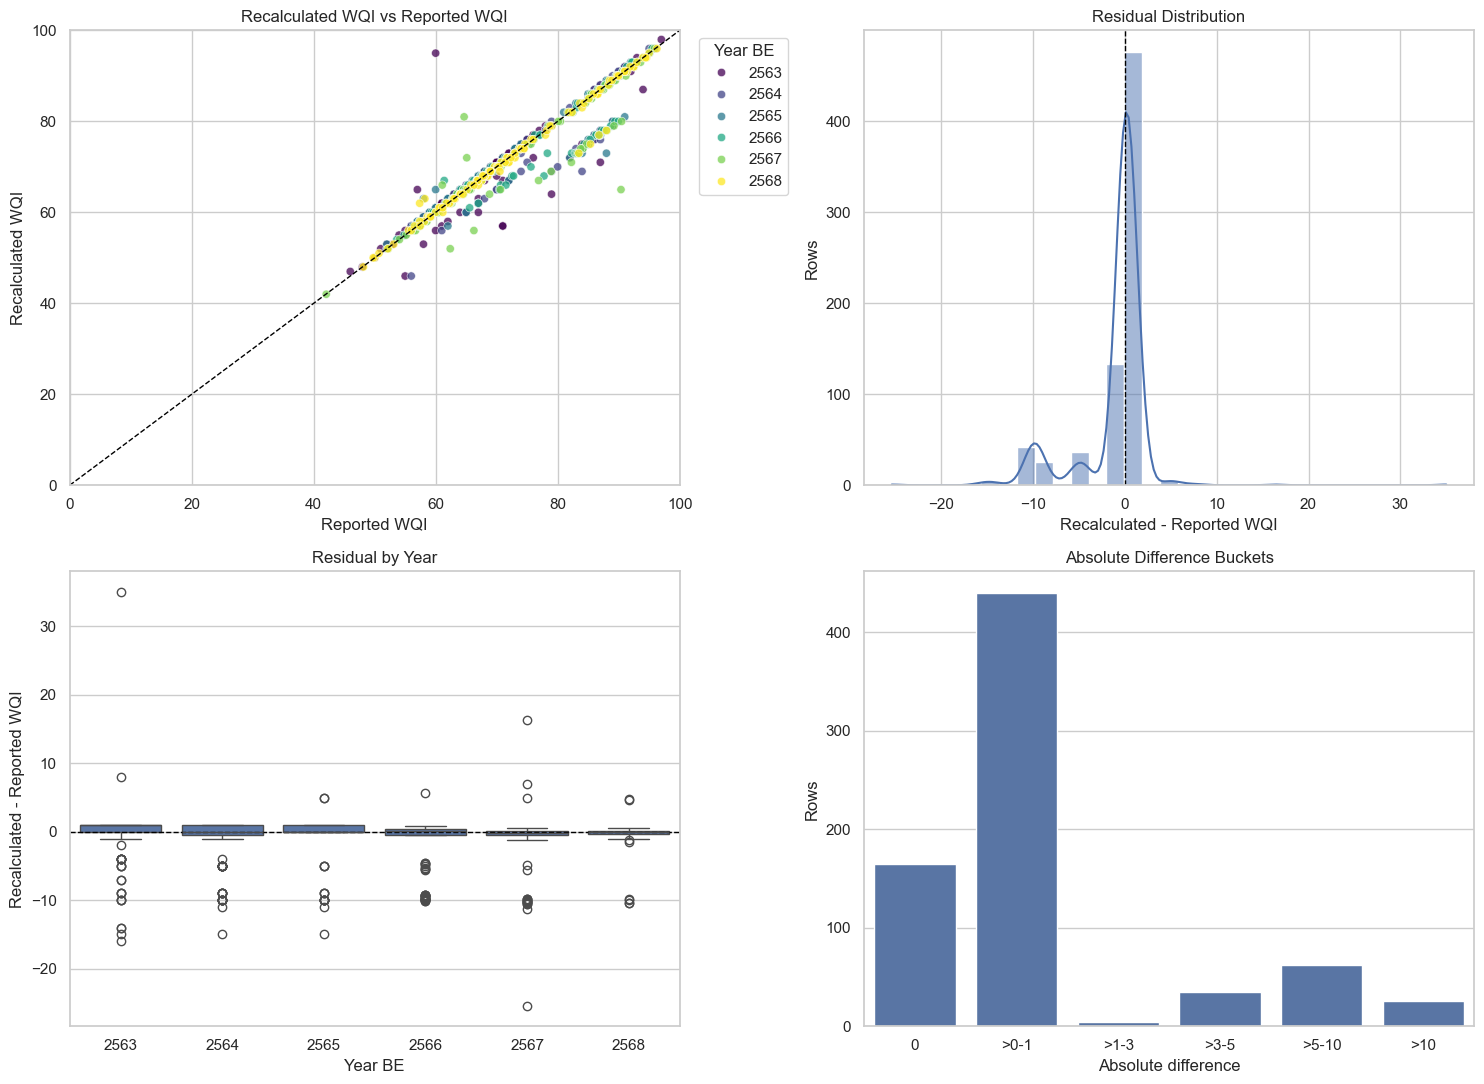

Top 20 rows with largest absolute difference


,year_be,station_original,station_canonical,survey_no,survey_date,DO_mg_l_clean,BOD_mg_l_clean,TCB_MPN_100ml_clean,FCB_MPN_100ml_clean,NH3_N_mg_l_clean,WQI_reported,WQI_recalc_pcd5,WQI_diff_recalc_minus_reported,WQI_abs_diff
156,2563,LS04,LS04,3//63,2020-06-08,8.30,0.6,1100.0,78.0,0.042426,60.000000,95.0,35.000000,35.000000
654,2567,TP09,TP09,2//67,2024-04-25,6.00,1.3,1700.0,1100.0,0.300000,90.387060,65.0,-25.387060,25.387060
652,2567,TP07,TP07,2//67,2024-04-29,4.40,0.3,17.0,2.0,0.007071,64.664360,81.0,16.335640,16.335640
155,2563,LS03,LS03,3//63,2020-06-08,7.40,0.8,5400.0,1700.0,0.042426,87.000000,71.0,-16.000000,16.000000
295,2564,PN13,PN13,3//64,2021-07-29,10.00,0.5,350.0,350.0,0.042426,84.000000,69.0,-15.000000,15.000000
391,2565,TP11,TP11,3//65,2022-07-19,9.05,0.5,700.0,33.0,0.042426,88.000000,73.0,-15.000000,15.000000
140,2563,PN13,PN13,4//63,2020-07-14,9.45,0.9,2800.0,700.0,0.042426,79.000000,64.0,-15.000000,15.000000
158,2563,CP02,CP02,3//63,2020-06-08,4.57,0.9,16000.0,16000.0,0.042426,71.000000,57.0,-14.000000,14.000000
197,2563,PN01,PN01,2//63,2020-02-12,3.65,1.0,2400.0,1300.0,0.353553,71.000000,57.0,-14.000000,14.000000
653,2567,TP08,TP08,2//67,2024-04-25,6.80,2.2,540.0,240.0,0.007071,82.256300,71.0,-11.256300,11.256300


In [134]:
try:
    from IPython.display import display
except ImportError:
    display = print

wqi_compare = rs_ready[
    rs_ready["year_be"].between(2563, 2568)
    & rs_ready["WQI_reported"].notna()
    & rs_ready["WQI_recalc_pcd5"].notna()
].copy()

wqi_formula_missing = rs_ready[
    rs_ready["year_be"].between(2563, 2568)
    & rs_ready["WQI_reported"].notna()
    & rs_ready["WQI_recalc_pcd5"].isna()
].copy()

wqi_compare["WQI_diff_recalc_minus_reported"] = (
    wqi_compare["WQI_recalc_pcd5"] - wqi_compare["WQI_reported"]
)
wqi_compare["WQI_abs_diff"] = wqi_compare["WQI_diff_recalc_minus_reported"].abs()

summary_overall = pd.DataFrame({
    "metric": [
        "rows_compared",
        "mean_diff_recalc_minus_reported",
        "median_diff_recalc_minus_reported",
        "mean_abs_diff",
        "median_abs_diff",
        "p90_abs_diff",
        "p95_abs_diff",
        "max_abs_diff",
        "rows_missing_recalc_formula",
    ],
    "value": [
        len(wqi_compare),
        wqi_compare["WQI_diff_recalc_minus_reported"].mean(),
        wqi_compare["WQI_diff_recalc_minus_reported"].median(),
        wqi_compare["WQI_abs_diff"].mean(),
        wqi_compare["WQI_abs_diff"].median(),
        wqi_compare["WQI_abs_diff"].quantile(0.90),
        wqi_compare["WQI_abs_diff"].quantile(0.95),
        wqi_compare["WQI_abs_diff"].max(),
        len(wqi_formula_missing),
    ],
})

summary_by_year = (
    wqi_compare
    .groupby("year_be")
    .agg(
        rows=("WQI_diff_recalc_minus_reported", "size"),
        mean_diff=("WQI_diff_recalc_minus_reported", "mean"),
        median_diff=("WQI_diff_recalc_minus_reported", "median"),
        mean_abs_diff=("WQI_abs_diff", "mean"),
        median_abs_diff=("WQI_abs_diff", "median"),
        max_abs_diff=("WQI_abs_diff", "max"),
    )
    .round(3)
    .reset_index()
)

print("Overall validation summary")
display(summary_overall.round(3))

print("Validation summary by year")
display(summary_by_year)

if len(wqi_formula_missing) > 0:
    print("Rows with reported WQI but no recalculated WQI because formula coverage/input was missing")
    display(wqi_formula_missing[[
        "year_be", "station_original", "station_canonical", "survey_no", "survey_date",
        "DO_mg_l_clean", "BOD_mg_l_clean", "TCB_MPN_100ml_clean",
        "FCB_MPN_100ml_clean", "NH3_N_mg_l_clean", "WQI_reported",
    ]])

wqi_compare["abs_diff_bucket"] = pd.cut(
    wqi_compare["WQI_abs_diff"],
    bins=[-0.1, 0, 1, 3, 5, 10, np.inf],
    labels=["0", ">0-1", ">1-3", ">3-5", ">5-10", ">10"],
)
abs_bucket_counts = (
    wqi_compare["abs_diff_bucket"]
    .value_counts(sort=False)
    .rename_axis("abs_diff_bucket")
    .reset_index(name="rows")
)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

sns.scatterplot(
    data=wqi_compare,
    x="WQI_reported",
    y="WQI_recalc_pcd5",
    hue="year_be",
    palette="viridis",
    alpha=0.75,
    ax=axes[0, 0],
)
axes[0, 0].plot([0, 100], [0, 100], linestyle="--", color="black", linewidth=1)
axes[0, 0].set_title("Recalculated WQI vs Reported WQI")
axes[0, 0].set_xlabel("Reported WQI")
axes[0, 0].set_ylabel("Recalculated WQI")
axes[0, 0].set_xlim(0, 100)
axes[0, 0].set_ylim(0, 100)
axes[0, 0].legend(title="Year BE", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.histplot(
    data=wqi_compare,
    x="WQI_diff_recalc_minus_reported",
    bins=31,
    kde=True,
    ax=axes[0, 1],
)
axes[0, 1].axvline(0, linestyle="--", color="black", linewidth=1)
axes[0, 1].set_title("Residual Distribution")
axes[0, 1].set_xlabel("Recalculated - Reported WQI")
axes[0, 1].set_ylabel("Rows")

sns.boxplot(
    data=wqi_compare,
    x="year_be",
    y="WQI_diff_recalc_minus_reported",
    ax=axes[1, 0],
)
axes[1, 0].axhline(0, linestyle="--", color="black", linewidth=1)
axes[1, 0].set_title("Residual by Year")
axes[1, 0].set_xlabel("Year BE")
axes[1, 0].set_ylabel("Recalculated - Reported WQI")

sns.barplot(
    data=abs_bucket_counts,
    x="abs_diff_bucket",
    y="rows",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Absolute Difference Buckets")
axes[1, 1].set_xlabel("Absolute difference")
axes[1, 1].set_ylabel("Rows")

plt.tight_layout()
plt.show()

outlier_cols = [
    "year_be", "station_original", "station_canonical", "survey_no", "survey_date",
    "DO_mg_l_clean", "BOD_mg_l_clean", "TCB_MPN_100ml_clean",
    "FCB_MPN_100ml_clean", "NH3_N_mg_l_clean",
    "WQI_reported", "WQI_recalc_pcd5",
    "WQI_diff_recalc_minus_reported", "WQI_abs_diff",
]

print("Top 20 rows with largest absolute difference")
display(
    wqi_compare
    .sort_values("WQI_abs_diff", ascending=False)
    [outlier_cols]
    .head(20)
)

### 5.2 Outlier analysis for WQI inputs, WQI scores, SS, and turbidity

This section is exploratory QC. It flags suspicious values for inspection but does not remove rows automatically.

Targets checked here:

- WQI input measurements: `DO_mg_l_clean`, `BOD_mg_l_clean`, `TCB_MPN_100ml_clean`, `FCB_MPN_100ml_clean`, `NH3_N_mg_l_clean`
- Final WQI: `WQI_clean`
- WQI subindex scores: `WQI_DO_score_pcd5`, `WQI_BOD_score_pcd5`, `WQI_TCB_score_pcd5`, `WQI_FCB_score_pcd5`, `WQI_NH3_score_pcd5`
- Optical/solid-related field parameters: `SS_mg_l_clean`, `turbidity_NTU_clean`

Flagging logic:

1. `global_iqr_outlier`: robust IQR rule across the whole RS-ready dataset for each parameter.
2. `year_iqr_outlier`: robust IQR rule within each year, used only when that parameter-year group has enough rows.
3. `plausibility_outlier`: simple physical/data-validity bounds, for example WQI and WQI scores must be 0-100, and concentration-like variables should not be negative.

For highly skewed variables such as `TCB`, `FCB`, `SS`, and `turbidity`, IQR is applied on `log10(value + 1)` so very large but plausible pollution events are handled more fairly.

Outlier summary by parameter


,parameter_group,parameter_label,parameter,plot_scale,rows,missing,min_value,median_value,max_value,global_iqr_lower_raw,global_iqr_upper_raw,global_iqr_outliers,year_iqr_outliers,plausibility_outliers,any_outliers,any_outlier_pct
0,Optical/solid,SS,SS_mg_l_clean,log10(value+1),826,0,7.071,14.000,848.000,-0.067,292.969,12,5,0,12,1.453
1,Optical/solid,Turbidity,turbidity_NTU_clean,log10(value+1),826,0,0.000,16.050,989.000,-0.335,504.229,5,3,0,7,0.847
2,WQI final,WQI final,WQI_clean,raw value,826,0,38.000,70.000,97.000,31.500,115.500,0,8,0,8,0.969
6,WQI input,NH3-N,NH3_N_mg_l_clean,raw value,826,0,0.007,0.042,0.520,-0.074,0.236,106,6,0,106,12.833
3,WQI input,BOD,BOD_mg_l_clean,raw value,826,0,0.000,1.200,8.800,-0.450,3.150,47,46,0,53,6.416
7,WQI input,TCB,TCB_MPN_100ml_clean,log10(value+1),826,0,1.273,2200.000,240000.000,31.778,115506.030,32,26,0,37,4.479
4,WQI input,DO,DO_mg_l_clean,raw value,826,0,0.000,6.480,11.600,2.700,9.900,15,14,0,22,2.663
5,WQI input,FCB,FCB_MPN_100ml_clean,log10(value+1),826,0,1.273,490.000,240000.000,0.902,151579.440,3,6,0,8,0.969
11,WQI subindex score,NH3-N score,WQI_NH3_score_pcd5,raw value,826,0,60.549,94.407,99.068,68.843,109.746,90,0,0,90,10.896
8,WQI subindex score,BOD score,WQI_BOD_score_pcd5,raw value,826,0,0.000,76.800,100.000,38.600,109.001,32,36,0,44,5.327


Outlier summary by parameter and year


,parameter_group,parameter_label,year_be,rows,any_outliers,any_outlier_pct
0,Optical/solid,SS,2562,93,0,0.00
1,Optical/solid,SS,2563,153,0,0.00
2,Optical/solid,SS,2564,115,4,3.48
3,Optical/solid,SS,2565,93,2,2.15
4,Optical/solid,SS,2566,124,2,1.61
...,...,...,...,...,...,...
86,WQI subindex score,TCB score,2564,115,1,0.87
87,WQI subindex score,TCB score,2565,93,0,0.00
88,WQI subindex score,TCB score,2566,124,1,0.81
89,WQI subindex score,TCB score,2567,124,1,0.81


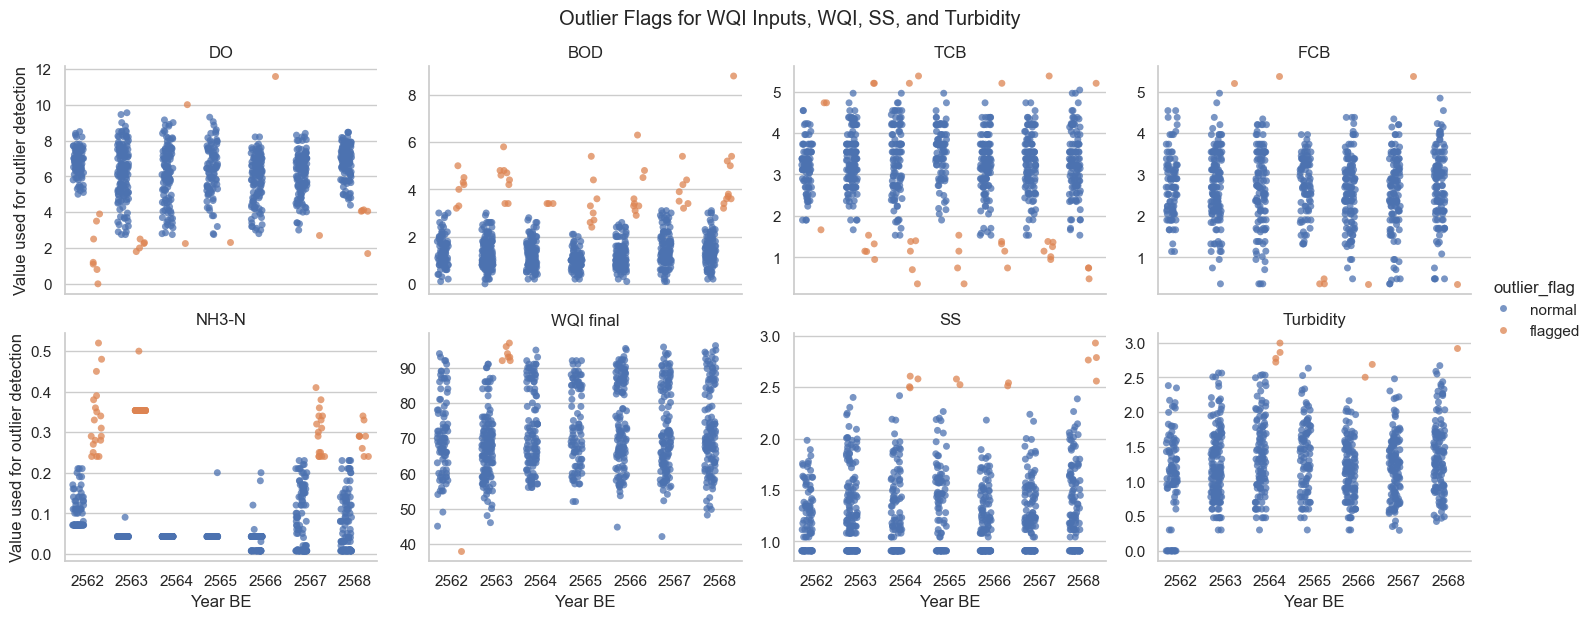

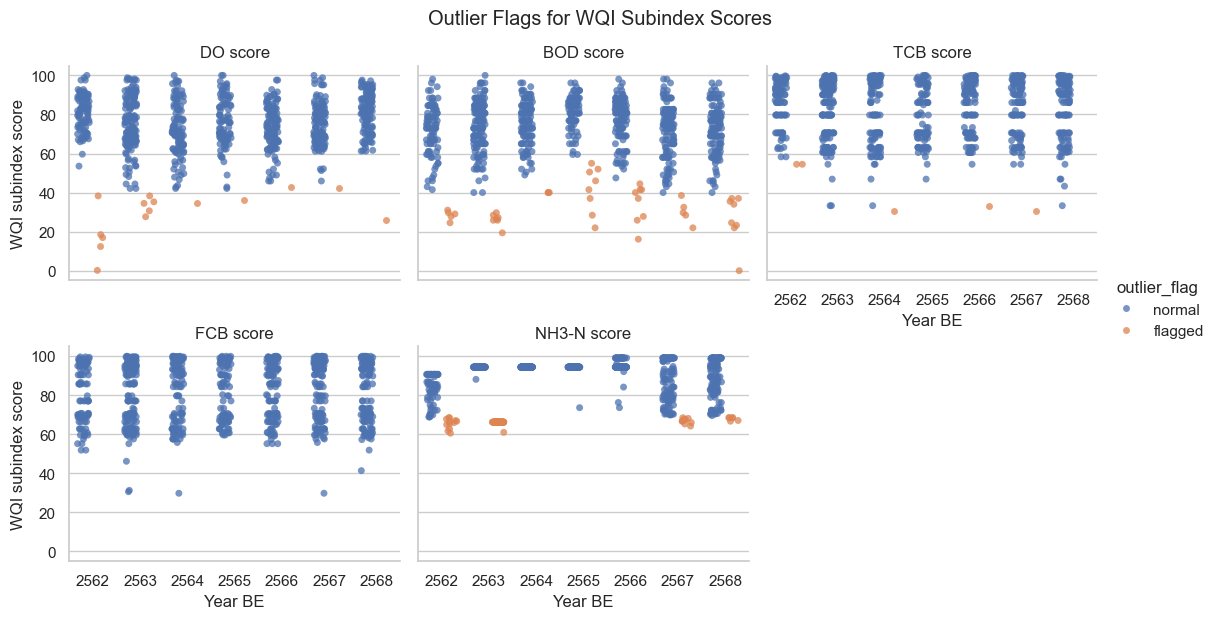

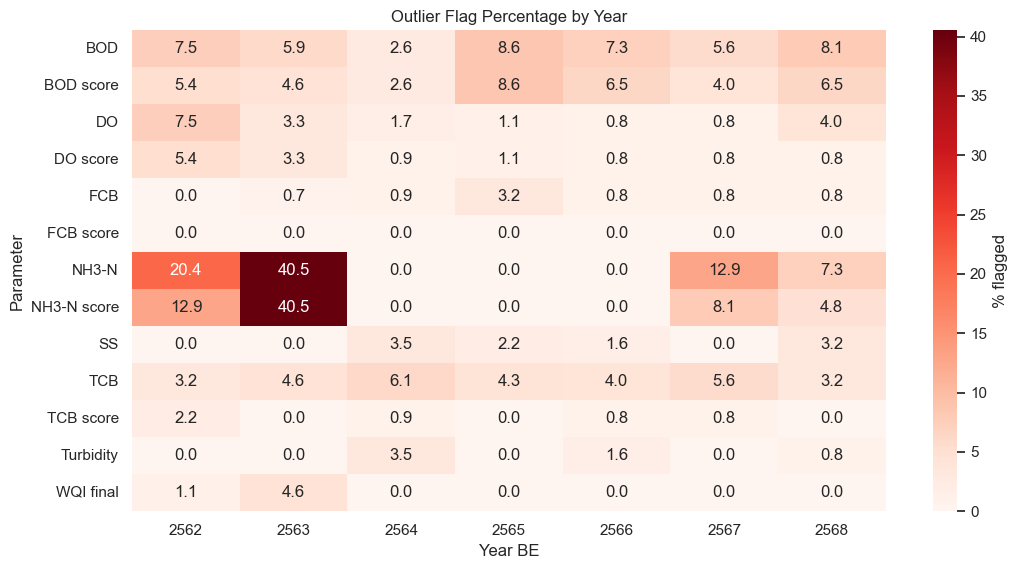

Top outlier candidates for manual inspection


,parameter_group,parameter_label,parameter,value,plot_scale,outlier_reason,global_iqr_lower_raw,global_iqr_upper_raw,global_iqr_severity,year_be,survey_no,survey_date,station_original,station_canonical,water_body,coordinate_waterbody
1647,WQI input,BOD,BOD_mg_l_clean,8.800,raw value,global_iqr;year_iqr,-0.450,3.150,6.278,2568,4//68,2025-11-10,PN04,PN04,ภาคใต้ฝั่งตะวันออกตอนบน,แม่น้ำปากพนัง
3374,WQI input,NH3-N,NH3_N_mg_l_clean,0.520,raw value,global_iqr;year_iqr,-0.074,0.236,3.656,2562,1//62,2019-02-12,PN02,PN02,ปากพนัง,แม่น้ำปากพนัง
1367,WQI input,BOD,BOD_mg_l_clean,6.300,raw value,global_iqr;year_iqr,-0.450,3.150,3.500,2566,3//66,2023-07-05,PN02,PN02,ปากพนัง,แม่น้ำปากพนัง
3526,WQI input,NH3-N,NH3_N_mg_l_clean,0.500,raw value,global_iqr,-0.074,0.236,3.399,2563,1//63,2020-01-09,TP01,TP01,ตาปี,แม่น้ำตาปีตอนล่าง
3363,WQI input,NH3-N,NH3_N_mg_l_clean,0.480,raw value,global_iqr;year_iqr,-0.074,0.236,3.141,2562,2//62,2019-05-22,SK06,SK06,ทะเลหลวง,ทะเลหลวง
1020,WQI input,BOD,BOD_mg_l_clean,5.800,raw value,global_iqr;year_iqr,-0.450,3.150,2.944,2563,2//63,2020-02-06,SK06,SK06,ทะเลหลวง,ทะเลหลวง
3312,WQI input,NH3-N,NH3_N_mg_l_clean,0.450,raw value,global_iqr;year_iqr,-0.074,0.236,2.754,2562,3//62,2019-07-31,PN02,PN02,ปากพนัง,แม่น้ำปากพนัง
1195,WQI input,BOD,BOD_mg_l_clean,5.400,raw value,global_iqr;year_iqr,-0.450,3.150,2.500,2565,3//65,2022-07-05,CP03,CP03,ชุมพร,แม่น้ำชุมพร
1494,WQI input,BOD,BOD_mg_l_clean,5.400,raw value,global_iqr;year_iqr,-0.450,3.150,2.500,2567,2//67,2024-04-24,PN11,PN11,ทะเลสาบสงขลา,แม่น้ำปากพนัง
1638,WQI input,BOD,BOD_mg_l_clean,5.400,raw value,global_iqr;year_iqr,-0.450,3.150,2.500,2568,4//68,2025-11-18,LS04,LS04,ภาคใต้ฝั่งตะวันออกตอนบน,แม่น้ำหลังสวนตอนบน


In [135]:
try:
    from IPython.display import display
except ImportError:
    display = print

OUTLIER_CONFIG = [
    {"column": "DO_mg_l_clean", "label": "DO", "group": "WQI input", "log_iqr": False, "plausible_min": 0, "plausible_max": 20},
    {"column": "BOD_mg_l_clean", "label": "BOD", "group": "WQI input", "log_iqr": False, "plausible_min": 0, "plausible_max": None},
    {"column": "TCB_MPN_100ml_clean", "label": "TCB", "group": "WQI input", "log_iqr": True, "plausible_min": 0, "plausible_max": None},
    {"column": "FCB_MPN_100ml_clean", "label": "FCB", "group": "WQI input", "log_iqr": True, "plausible_min": 0, "plausible_max": None},
    {"column": "NH3_N_mg_l_clean", "label": "NH3-N", "group": "WQI input", "log_iqr": False, "plausible_min": 0, "plausible_max": None},
    {"column": "WQI_clean", "label": "WQI final", "group": "WQI final", "log_iqr": False, "plausible_min": 0, "plausible_max": 100},
    {"column": "WQI_DO_score_pcd5", "label": "DO score", "group": "WQI subindex score", "log_iqr": False, "plausible_min": 0, "plausible_max": 100},
    {"column": "WQI_BOD_score_pcd5", "label": "BOD score", "group": "WQI subindex score", "log_iqr": False, "plausible_min": 0, "plausible_max": 100},
    {"column": "WQI_TCB_score_pcd5", "label": "TCB score", "group": "WQI subindex score", "log_iqr": False, "plausible_min": 0, "plausible_max": 100},
    {"column": "WQI_FCB_score_pcd5", "label": "FCB score", "group": "WQI subindex score", "log_iqr": False, "plausible_min": 0, "plausible_max": 100},
    {"column": "WQI_NH3_score_pcd5", "label": "NH3-N score", "group": "WQI subindex score", "log_iqr": False, "plausible_min": 0, "plausible_max": 100},
    {"column": "SS_mg_l_clean", "label": "SS", "group": "Optical/solid", "log_iqr": True, "plausible_min": 0, "plausible_max": None},
    {"column": "turbidity_NTU_clean", "label": "Turbidity", "group": "Optical/solid", "log_iqr": True, "plausible_min": 0, "plausible_max": None},
]

OUTLIER_META_COLS = [
    "year_be", "survey_no", "survey_date", "station_original", "station_canonical",
    "water_body", "coordinate_waterbody", "WQI_source",
]
OUTLIER_META_COLS = [c for c in OUTLIER_META_COLS if c in rs_ready.columns]


def _iqr_bounds(values, multiplier=1.5):
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    if pd.isna(iqr) or iqr == 0:
        return q1, q3, iqr, np.nan, np.nan
    return q1, q3, iqr, q1 - multiplier * iqr, q3 + multiplier * iqr


def _to_iqr_scale(values, use_log):
    values = pd.to_numeric(values, errors="coerce")
    if use_log:
        return np.log10(values.clip(lower=0) + 1)
    return values


def _from_iqr_scale(values, use_log):
    if use_log:
        return np.power(10, values) - 1
    return values

outlier_parts = []
for cfg in OUTLIER_CONFIG:
    col = cfg["column"]
    if col not in rs_ready.columns:
        continue

    temp = rs_ready[OUTLIER_META_COLS + [col]].copy()
    temp = temp.rename(columns={col: "value"})
    temp["value"] = pd.to_numeric(temp["value"], errors="coerce")
    temp = temp[temp["value"].notna()].copy()
    if temp.empty:
        continue

    temp["parameter"] = col
    temp["parameter_label"] = cfg["label"]
    temp["parameter_group"] = cfg["group"]
    temp["log_iqr"] = cfg["log_iqr"]
    temp["iqr_value"] = _to_iqr_scale(temp["value"], cfg["log_iqr"])

    q1, q3, iqr, lower, upper = _iqr_bounds(temp["iqr_value"])
    temp["global_q1"] = q1
    temp["global_q3"] = q3
    temp["global_iqr"] = iqr
    temp["global_iqr_lower"] = lower
    temp["global_iqr_upper"] = upper
    temp["global_iqr_lower_raw"] = _from_iqr_scale(lower, cfg["log_iqr"]) if pd.notna(lower) else np.nan
    temp["global_iqr_upper_raw"] = _from_iqr_scale(upper, cfg["log_iqr"]) if pd.notna(upper) else np.nan

    if pd.notna(lower) and pd.notna(upper):
        temp["global_iqr_outlier"] = (temp["iqr_value"] < lower) | (temp["iqr_value"] > upper)
        distance = np.maximum(temp["iqr_value"] - upper, lower - temp["iqr_value"])
        temp["global_iqr_severity"] = np.where(temp["global_iqr_outlier"], distance / iqr, 0)
    else:
        temp["global_iqr_outlier"] = False
        temp["global_iqr_severity"] = 0.0

    year_bounds = (
        temp
        .groupby("year_be")["iqr_value"]
        .agg(
            year_n="size",
            year_q1=lambda s: s.quantile(0.25),
            year_q3=lambda s: s.quantile(0.75),
        )
        .reset_index()
    )
    year_bounds["year_iqr"] = year_bounds["year_q3"] - year_bounds["year_q1"]
    year_bounds["year_iqr_lower"] = year_bounds["year_q1"] - 1.5 * year_bounds["year_iqr"]
    year_bounds["year_iqr_upper"] = year_bounds["year_q3"] + 1.5 * year_bounds["year_iqr"]
    temp = temp.merge(year_bounds, on="year_be", how="left")
    enough_year_rows = temp["year_n"] >= 10
    valid_year_iqr = temp["year_iqr"].notna() & (temp["year_iqr"] > 0)
    temp["year_iqr_outlier"] = (
        enough_year_rows
        & valid_year_iqr
        & ((temp["iqr_value"] < temp["year_iqr_lower"]) | (temp["iqr_value"] > temp["year_iqr_upper"]))
    )

    plausible = pd.Series(False, index=temp.index)
    if cfg["plausible_min"] is not None:
        plausible = plausible | (temp["value"] < cfg["plausible_min"])
    if cfg["plausible_max"] is not None:
        plausible = plausible | (temp["value"] > cfg["plausible_max"])
    temp["plausibility_outlier"] = plausible

    temp["any_outlier"] = (
        temp["global_iqr_outlier"]
        | temp["year_iqr_outlier"]
        | temp["plausibility_outlier"]
    )
    temp["outlier_flag"] = np.where(temp["any_outlier"], "flagged", "normal")
    temp["plot_value"] = temp["iqr_value"]
    temp["plot_scale"] = np.where(cfg["log_iqr"], "log10(value+1)", "raw value")

    reason_parts = []
    for _, row in temp.iterrows():
        reasons = []
        if row["global_iqr_outlier"]:
            reasons.append("global_iqr")
        if row["year_iqr_outlier"]:
            reasons.append("year_iqr")
        if row["plausibility_outlier"]:
            reasons.append("plausibility")
        reason_parts.append(";".join(reasons) if reasons else "normal")
    temp["outlier_reason"] = reason_parts

    outlier_parts.append(temp)

outlier_flags = pd.concat(outlier_parts, ignore_index=True)

outlier_summary = (
    outlier_flags
    .groupby(["parameter_group", "parameter_label", "parameter", "plot_scale"])
    .agg(
        rows=("value", "size"),
        missing=("value", lambda s: int(s.isna().sum())),
        min_value=("value", "min"),
        median_value=("value", "median"),
        max_value=("value", "max"),
        global_iqr_lower_raw=("global_iqr_lower_raw", "first"),
        global_iqr_upper_raw=("global_iqr_upper_raw", "first"),
        global_iqr_outliers=("global_iqr_outlier", "sum"),
        year_iqr_outliers=("year_iqr_outlier", "sum"),
        plausibility_outliers=("plausibility_outlier", "sum"),
        any_outliers=("any_outlier", "sum"),
    )
    .reset_index()
)
outlier_summary["any_outlier_pct"] = 100 * outlier_summary["any_outliers"] / outlier_summary["rows"]

outlier_year_summary = (
    outlier_flags
    .groupby(["parameter_group", "parameter_label", "year_be"])
    .agg(rows=("value", "size"), any_outliers=("any_outlier", "sum"))
    .reset_index()
)
outlier_year_summary["any_outlier_pct"] = 100 * outlier_year_summary["any_outliers"] / outlier_year_summary["rows"]

print("Outlier summary by parameter")
display(outlier_summary.round(3).sort_values(["parameter_group", "any_outlier_pct"], ascending=[True, False]))

print("Outlier summary by parameter and year")
display(outlier_year_summary.round(2).sort_values(["parameter_group", "parameter_label", "year_be"]))

plot_groups = ["WQI input", "WQI final", "Optical/solid"]
plot_data = outlier_flags[outlier_flags["parameter_group"].isin(plot_groups)].copy()

if not plot_data.empty:
    g = sns.catplot(
        data=plot_data,
        x="year_be",
        y="plot_value",
        hue="outlier_flag",
        col="parameter_label",
        col_wrap=4,
        kind="strip",
        dodge=True,
        jitter=0.25,
        alpha=0.75,
        height=3,
        aspect=1.25,
        sharey=False,
    )
    g.set_titles("{col_name}")
    g.set_axis_labels("Year BE", "Value used for outlier detection")
    g.fig.suptitle("Outlier Flags for WQI Inputs, WQI, SS, and Turbidity", y=1.03)
    plt.show()

score_plot = outlier_flags[outlier_flags["parameter_group"] == "WQI subindex score"].copy()
if not score_plot.empty:
    g = sns.catplot(
        data=score_plot,
        x="year_be",
        y="value",
        hue="outlier_flag",
        col="parameter_label",
        col_wrap=3,
        kind="strip",
        dodge=True,
        jitter=0.25,
        alpha=0.75,
        height=3,
        aspect=1.25,
        sharey=True,
    )
    g.set_titles("{col_name}")
    g.set_axis_labels("Year BE", "WQI subindex score")
    g.fig.suptitle("Outlier Flags for WQI Subindex Scores", y=1.03)
    plt.show()

heatmap_data = outlier_year_summary.pivot_table(
    index="parameter_label",
    columns="year_be",
    values="any_outlier_pct",
    aggfunc="mean",
)
plt.figure(figsize=(11, max(5, 0.45 * len(heatmap_data))))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="Reds", cbar_kws={"label": "% flagged"})
plt.title("Outlier Flag Percentage by Year")
plt.xlabel("Year BE")
plt.ylabel("Parameter")
plt.tight_layout()
plt.show()

outlier_detail_cols = [
    "parameter_group", "parameter_label", "parameter", "value", "plot_scale",
    "outlier_reason", "global_iqr_lower_raw", "global_iqr_upper_raw",
    "global_iqr_severity", "year_be", "survey_no", "survey_date",
    "station_original", "station_canonical", "water_body", "coordinate_waterbody",
]
outlier_detail_cols = [c for c in outlier_detail_cols if c in outlier_flags.columns]

top_outlier_candidates = (
    outlier_flags[outlier_flags["any_outlier"]]
    .sort_values(["plausibility_outlier", "global_iqr_severity"], ascending=[False, False])
    [outlier_detail_cols]
    .head(60)
)

print("Top outlier candidates for manual inspection")
display(top_outlier_candidates.round(3))

In [136]:
model_base.columns

Index(['water_body', 'survey_no', 'station', 'survey_date', 'survey_time',
       'depth_m', 'temp_air', 'temp_water', 'pH', 'turbidity_NTU',
       ...
       'coordinate_assignment_note', 'canonical_station_survey_id',
       'coordinate_years_documented', 'latitude', 'longitude',
       'station_location', 'coordinate_waterbody', 'coordinate_source',
       'coordinate_crs', 'coordinate_status'],
      dtype='str', length=116)

In [137]:
clean_cols = [
    "year_be", "year_ad", "survey_no", "survey_date", "survey_time",
    "station_survey_id", "station", "station_original", "station_canonical", "canonical_station_survey_id",
    "latitude", "longitude", "station_location", "coordinate_waterbody",
    "coordinate_assignment_status", "coordinate_assignment_note",
    "rs_use_status", "rs_exclusion_reason",
    "water_body", "source_file", "source_sheet",
]

clean_value_cols = [
    "DO_mg_l_clean",
    "BOD_mg_l_clean",
    "turbidity_NTU_clean",
    "SS_mg_l_clean",
    "TCB_MPN_100ml_clean",
    "FCB_MPN_100ml_clean",
    "NH3_N_mg_l_clean",
    "WQI_clean",
    "WQI_reported",
    "WQI_recalc_pcd5",
    "WQI_source",
    "WQI_recalc_status",
    "WQI_mean_subindex_pcd5",
    "WQI_adjustment_pcd5",
    "WQI_DO_score_pcd5",
    "WQI_BOD_score_pcd5",
    "WQI_TCB_score_pcd5",
    "WQI_FCB_score_pcd5",
    "WQI_NH3_score_pcd5",
    "pH_clean",
    "conductivity_clean",
    "salinity_ppt_clean",
    "temp_air_clean",
    "temp_water_clean",
]

# Preview-only tables for notebook inspection. These are not exported as CSV anymore.
clean_export = model_base[clean_cols + clean_value_cols].copy()
rs_clean_export = rs_ready[clean_cols + clean_value_cols].copy()

print("clean_export preview rows:", len(clean_export))
print("rs_clean_export preview rows:", len(rs_clean_export))
print("No readable CSV is exported. Use rs_ready as the single working CSV.")

clean_export preview rows: 856
rs_clean_export preview rows: 826
No readable CSV is exported. Use rs_ready as the single working CSV.


In [138]:
clean_export.columns

Index(['year_be', 'year_ad', 'survey_no', 'survey_date', 'survey_time',
       'station_survey_id', 'station', 'station_original', 'station_canonical',
       'canonical_station_survey_id', 'latitude', 'longitude',
       'station_location', 'coordinate_waterbody',
       'coordinate_assignment_status', 'coordinate_assignment_note',
       'rs_use_status', 'rs_exclusion_reason', 'water_body', 'source_file',
       'source_sheet', 'DO_mg_l_clean', 'BOD_mg_l_clean',
       'turbidity_NTU_clean', 'SS_mg_l_clean', 'TCB_MPN_100ml_clean',
       'FCB_MPN_100ml_clean', 'NH3_N_mg_l_clean', 'WQI_clean', 'WQI_reported',
       'WQI_recalc_pcd5', 'WQI_source', 'WQI_recalc_status',
       'WQI_mean_subindex_pcd5', 'WQI_adjustment_pcd5', 'WQI_DO_score_pcd5',
       'WQI_BOD_score_pcd5', 'WQI_TCB_score_pcd5', 'WQI_FCB_score_pcd5',
       'WQI_NH3_score_pcd5', 'pH_clean', 'conductivity_clean',
       'salinity_ppt_clean', 'temp_air_clean', 'temp_water_clean'],
      dtype='str')

In [139]:
clean_export.head()

,year_be,year_ad,survey_no,survey_date,survey_time,station_survey_id,station,station_original,station_canonical,canonical_station_survey_id,...,WQI_DO_score_pcd5,WQI_BOD_score_pcd5,WQI_TCB_score_pcd5,WQI_FCB_score_pcd5,WQI_NH3_score_pcd5,pH_clean,conductivity_clean,salinity_ppt_clean,temp_air_clean,temp_water_clean
0,2562,2019,3//62,2019-07-22,12:15:00,LS01_3_62,LS01,LS01,LS01,LS01_3_62,...,83.0810,96.1334,67.893,69.713,78.90880,7.2,2020.0,1.0,32.8,28.7
1,2562,2019,3//62,2019-07-22,11:40:00,LS02_3_62,LS02,LS02,LS02,LS02_3_62,...,87.9142,72.9338,86.080,70.043,89.45440,7.7,76.0,0.0,31.5,27.6
2,2562,2019,3//62,2019-07-22,11:10:00,LS03_3_62,LS03,LS03,LS03,LS03_3_62,...,87.9142,76.8004,79.700,77.090,84.18160,7.9,60.0,0.0,31.0,27.5
3,2562,2019,3//62,2019-07-22,10:30:00,LS04_3_62,LS04,LS04,LS04,LS04_3_62,...,91.5391,88.4002,79.700,70.043,82.86340,8.7,65.0,0.0,31.0,28.1
4,2562,2019,3//62,2019-07-23,12:20:00,CP01_3_62,CP01,CP01,CP01,CP01_3_62,...,67.0000,84.5336,70.553,62.783,64.92854,7.2,22150.0,13.3,37.5,30.6


In [140]:
MODEL_TARGETS = [
    "DO_mg_l",
    "BOD_mg_l",
    "turbidity_NTU",
    "SS_mg_l",
    "TCB_MPN_100ml",
    "FCB_MPN_100ml",
    "NH3_N_mg_l",
    "WQI",
]

model_base_cols = [
    "year_be", "year_ad", "survey_no", "survey_date", "survey_time",
    "station_survey_id", "station", "station_original", "station_canonical", "canonical_station_survey_id",
    "latitude", "longitude", "station_location", "coordinate_waterbody",
    "coordinate_assignment_status", "coordinate_assignment_note",
    "water_body", "source_file", "source_sheet"
]

def make_model_ready(target, base=rs_ready):
    """Build a model-ready dataframe for one target from rs_ready without exporting a CSV."""
    target_clean = f"{target}_clean"
    target_type = f"{target}_value_type"
    if target_clean not in base.columns:
        raise KeyError(f"Missing clean target column: {target_clean}")

    cols = model_base_cols + [target_clean]
    if target_type in base.columns:
        cols.append(target_type)

    if target == "WQI":
        wqi_audit_cols = [
            "WQI_reported",
            "WQI_recalc_pcd5",
            "WQI_source",
            "WQI_recalc_status",
            "WQI_mean_subindex_pcd5",
            "WQI_adjustment_pcd5",
        ]
        cols.extend([c for c in wqi_audit_cols if c in base.columns])

    df_target = base[cols].copy()
    df_target = df_target.dropna(subset=[target_clean])
    df_target = df_target.rename(columns={
        target_clean: "target_value",
        target_type: "target_value_type",
    })
    df_target["target_name"] = target
    return df_target

# Example: create an in-memory model table when needed.
# model_ready_wqi = make_model_ready("WQI")
# model_ready_wqi.head()

model_ready_summary = pd.DataFrame([
    {
        "target": target,
        "rows_if_built": len(make_model_ready(target)),
        "censored_rows": int((make_model_ready(target).get("target_value_type") == "below_detection").sum())
    }
    for target in MODEL_TARGETS
])

model_ready_summary

,target,rows_if_built,censored_rows
0,DO_mg_l,826,0
1,BOD_mg_l,826,0
2,turbidity_NTU,826,0
3,SS_mg_l,826,295
4,TCB_MPN_100ml,826,3
5,FCB_MPN_100ml,826,15
6,NH3_N_mg_l,826,587
7,WQI,826,0


## 6. Exported CSV guide and data dictionary

ตอนนี้ notebook นี้ตั้งใจ export CSV แค่ 3 ไฟล์เท่านั้น เพื่อลดความรกและให้มี source of truth ชัดเจนสำหรับขั้นตอนถัดไป

ไฟล์ที่ export จริง:

1. `wq_14_2562_2568_rs_ready.csv`
2. `rs_excluded_station_coordinate_conflicts.csv`
3. `station_coordinate_reference.csv`

ไฟล์อื่นที่เคย export เช่น `clean_model_base.csv`, `*_readable.csv`, และ `model_ready_by_target/model_ready_{target}.csv` ถูกยกเลิกการ export แล้ว ถ้าต้องการดูหรือสร้างตารางแบบนั้น ให้สร้างเป็น dataframe ใน notebook ชั่วคราวจาก `model_base` หรือ `rs_ready` แทน

---

### เงื่อนไขร่วมก่อน export

- ใช้ข้อมูลปี `2562-2568`
- `survey_date` is normalized to AD/CE as `YYYY-MM-DD` before export; `year_be` keeps the original BE study year.
- อ่านเฉพาะ sheet รวมของแต่ละ Excel เช่น sheet ที่มีคำว่า `รวม` หรือ `1-4_2566`
- ข้ามไฟล์ lock/temp ของ Excel ที่ขึ้นต้นด้วย `~$`
- แถวที่ไม่มีทั้งวันที่และไม่มีค่าตรวจวัดจริงถูกตัดออกก่อนสร้าง `model_base`
  - เงื่อนไขคือ `row_qc_status == "missing_date_and_measurements"`
  - จากข้อมูลชุดนี้พบ 9 rows
- ค่าดิบยังถูกเก็บไว้ ไม่ถูก overwrite
- ค่าที่ clean แล้วอยู่ใน column `*_clean`
- ประเภทของค่าดิบอยู่ใน column `*_value_type`
- detection/reporting limit อยู่ใน column `*_detection_limit`
- ค่า `<DL` เช่น `<0.01` ถูกแปลงใน `*_clean` เป็น `DL / sqrt(2)`
- ค่า `>x` เช่น `>160000` ถูกแปลงใน `*_clean` เป็น `x` และควรตีความว่าเป็น lower bound
- `WQI_clean` is the final WQI used downstream: reported WQI is kept first, and only missing WQI is filled from `WQI_recalc_pcd5`.
- `WQI_reported` preserves the original reported WQI before filling missing values.
- `WQI_recalc_pcd5` is computed from the PCD/MNRE WQI-new five-parameter method: `DO`, `BOD`, `TCB`, `FCB`, and `NH3_N`.
- `WQI_adjustment_pcd5` uses adjustment values 0, 10, 15, and 20 based on the level gap between the mean-score quality level and the worst parameter level.
- `WQI_source` records whether the final WQI came from `reported`, `recalculated_pcd5`, or `missing_not_recalculated`.
- ค่า `-`, blank, `ND`, หรือ text ที่ parse ไม่ได้ ถูกแปลงเป็น `NaN` ใน `*_clean`
- พิกัดใช้ `latitude/longitude` ใน `EPSG:4326_latlon`
- ไม่แก้ `station` ดิบโดยตรง แต่สร้าง column audit แยก:
  - `station_original` = รหัสสถานีเดิมจาก Excel
  - `station_canonical` = รหัสสถานีที่ใช้ join พิกัด
  - `station_survey_id` = `station_original` + `survey_no`
  - `canonical_station_survey_id` = `station_canonical` + `survey_no`

---

### เงื่อนไข LS03 / LS03.1 และสถานีไม่มีพิกัด

เงื่อนไขนี้ใช้ตอนสร้าง `rs_ready` เพื่อให้ dataset ที่จะเอาไป match satellite ไม่ปน record ที่พิกัดไม่แน่นอน

- ปี `2567` รอบ `4//67`
  - `LS03.1` ถูก map ไปใช้พิกัด `LS03` เดิม เพราะคำอธิบายสถานีตรงกับ historical LS03
  - `LS03` ถูก exclude เพราะเอกสารรอบนี้ทำให้รหัสกับคำอธิบายสถานีขัดกัน
- ปี `2568`
  - `LS03.1` ถูก map ไปใช้พิกัด `LS03` แบบ `provisional` เพราะยังไม่มีเอกสารปี 2568 และใช้ assumption ตาม pattern ปี 2567
  - `LS03` ถูก exclude แบบ conservative เพราะภายใต้ assumption นี้ถือเป็นจุดใหม่ที่ยังไม่มีพิกัดยืนยัน
- `LS05`, `PN05`, `PN07`, `PN08`, `PN15` ถูก exclude จาก `rs_ready` เพราะไม่มีพิกัดยืนยันในเอกสารที่มี
- record ที่ถูก exclude ไม่ถูกลบทิ้ง แต่ถูก export ไปอยู่ใน `rs_excluded_station_coordinate_conflicts.csv`

---

### 1. `wq_14_2562_2568_rs_ready.csv`

ไฟล์หลักที่ใช้ทำงานต่อจริง ใช้เป็น base สำหรับ Sentinel/GEE matching, context feature matching และ train model หลังจากเพิ่ม satellite/context features แล้ว

จำนวนแถวปัจจุบัน: check latest output; current 2562-2568 rs_ready export has 826 rows

เงื่อนไขการสร้าง:

- เริ่มจาก `model_base` หลัง clean ค่าและ map พิกัด
- เก็บเฉพาะ `rs_use_status == "keep"`
- ต้องมี `latitude` และ `longitude`
- ไม่รวม station/record ที่ไม่มีพิกัดหรือมี station-code conflict
- รวม record ที่ `LS03.1` ถูก map ไป `LS03` ตาม rule ด้านบน

Column groups สำคัญ:

| กลุ่ม column | ตัวอย่าง | ความหมาย |
|---|---|---|
| source/audit | `source_file`, `source_sheet` | record มาจากไฟล์และ sheet ไหน |
| date/survey | `year_be`, `year_ad`, `survey_no`, `survey_date`, `survey_time` | ปี รอบสำรวจ วันที่ เวลา |
| station | `station`, `station_original`, `station_canonical` | รหัสสถานีดิบและรหัสที่ใช้ join พิกัด |
| ID | `station_survey_id`, `canonical_station_survey_id` | ID สำหรับ trace/match record |
| coordinate | `latitude`, `longitude`, `station_location`, `coordinate_waterbody` | พิกัดและ metadata จุดตรวจ |
| raw measurements | `DO_mg_l`, `BOD_mg_l`, `NH3_N_mg_l`, ... | ค่าดิบจาก Excel |
| clean measurements | `DO_mg_l_clean`, `BOD_mg_l_clean`, `turbidity_NTU_clean`, `SS_mg_l_clean`, `TCB_MPN_100ml_clean`, `FCB_MPN_100ml_clean`, `NH3_N_mg_l_clean`, `WQI_clean`, ... | ค่าที่ parse เป็นตัวเลขแล้ว |
| censor/QC | `*_value_type`, `*_detection_limit` | บอกว่าค่าดิบเป็น numeric ปกติ, `<DL`, `>x`, missing ฯลฯ |
| RS status | `rs_use_status`, `rs_exclusion_reason`, `coordinate_assignment_status`, `coordinate_assignment_note` | audit ว่า record นี้ใช้ RS ได้ไหม และพิกัดถูก assign อย่างไร |

ใช้ไฟล์นี้เมื่อ:

- จะ match Sentinel-2 / GEE ด้วย `latitude`, `longitude`, `survey_date`
- จะ merge rainfall, season, land use, tide/discharge หรือ context feature อื่น
- จะสร้าง final model dataset สำหรับ DO/BOD/Turbidity/SS/TCB/FCB/NH3/WQI
- จะ train baseline ชั่วคราว โดย filter target จาก wide table เองใน notebook

ข้อควรจำ:

- ไฟล์นี้ยังเป็น field + coordinate table ยังไม่มี satellite bands/features
- ถ้าทำนาย `WQI` ต้องระวัง leakage จาก parameter ที่ใช้คำนวณ WQI
- target non-optical เช่น `DO`, `BOD`, `NH3_N`, `TCB`, `FCB`, `WQI` ควรตีความเป็น proxy/risk estimation ไม่ใช่ satellite direct measurement

---

### 2. `rs_excluded_station_coordinate_conflicts.csv`

ไฟล์ audit ของ record ที่ถูกกันออกจาก `rs_ready` เพราะพิกัดหรือรหัสสถานีไม่มั่นใจ

จำนวนแถวปัจจุบัน: 30 rows

เหตุผลที่มีไฟล์นี้:

- เพื่อไม่ให้ข้อมูลที่ถูกตัดหายไปโดยไม่มีหลักฐาน
- เพื่อใช้ตอบใน method/paper ว่า exclude record ไหน เพราะอะไร
- เพื่อส่งต่อให้หน่วยงานช่วยยืนยันพิกัดในอนาคต

กลุ่ม record ที่ถูก exclude:

| station_original | จำนวน rows | เหตุผล |
|---|---:|---|
| `LS03` | 5 | ปี 2567 รอบ 4 และปี 2568 ถูกกันออกเพราะ code conflict / pending coordinate confirmation |
| `LS05` | 5 | ไม่มีพิกัดยืนยัน |
| `PN05` | 5 | ไม่มีพิกัดยืนยัน |
| `PN07` | 5 | ไม่มีพิกัดยืนยัน |
| `PN08` | 5 | ไม่มีพิกัดยืนยัน |
| `PN15` | 5 | ไม่มีพิกัดยืนยัน |

ใช้ไฟล์นี้เมื่อ:

- สงสัยว่าทำไมบางสถานีหายจาก `rs_ready`
- ต้องการ audit ผลกระทบจากการตัดข้อมูล
- ต้องการรายการสถานีที่ต้องขอพิกัดเพิ่ม

---

### 3. `station_coordinate_reference.csv`

ไฟล์ reference พิกัดสถานี ใช้เป็น lookup table สำหรับ join พิกัดเข้ากับ field data

จำนวนแถวปัจจุบัน: 32 coordinate rows

Columns:

| column | ความหมาย |
|---|---|
| `station_canonical` | รหัสสถานีที่ใช้เป็น key ตอน join พิกัด |
| `coordinate_years_documented` | ปีเอกสารที่พิกัดนี้ถูกอ้างอิง เช่น `64,65,66,67` |
| `latitude` | ละติจูด WGS84/EPSG:4326 |
| `longitude` | ลองจิจูด WGS84/EPSG:4326 |
| `station_location` | คำอธิบายจุดตรวจวัดจากตารางพิกัด |
| `coordinate_waterbody` | แหล่งน้ำตามตารางพิกัด |
| `coordinate_source` | แหล่งที่มาของพิกัด ตอนนี้คือ `user_provided_station_table` |
| `coordinate_crs` | CRS ของพิกัด ตอนนี้คือ `EPSG:4326_latlon` |
| `coordinate_status` | `coordinate_available` หรือ `missing_coordinate` |

ใช้ไฟล์นี้เมื่อ:

- ต้องการตรวจหรือแก้พิกัดสถานี
- ต้องการเพิ่มพิกัดสถานีใหม่ในอนาคต
- ต้องการดู metadata ของจุดตรวจวัด เช่น สถานที่และแหล่งน้ำ

---

### สิ่งที่ไม่ export แล้ว แต่ยังทำใน notebook ได้

- `model_base`: dataframe เต็มหลัง clean/map พิกัด มีทั้ง `keep` และ `exclude` ใช้ audit ใน memory
- `clean_export`, `rs_clean_export`: dataframe แบบอ่านง่ายสำหรับเปิดดูใน notebook ไม่เขียน CSV
- `make_model_ready(target)`: function สำหรับสร้าง model-ready dataframe ทีละ target จาก `rs_ready` ใน memory เช่น `make_model_ready("WQI")`

แนวทางใช้งานต่อ:

1. ใช้ `wq_14_2562_2568_rs_ready.csv` เป็นไฟล์หลัก
2. match satellite/context features เข้าไฟล์นี้
3. หลังมี feature แล้วค่อยสร้าง model-ready dataframe ทีละ target ใน notebook
4. ใช้ `rs_excluded_station_coordinate_conflicts.csv` และ `station_coordinate_reference.csv` เฉพาะ audit/reference

Reading e:\Water Quality Research\Data\tabular_data_14\02_intermediate\wq_14_2562_2568_rs_ready.csv
               DO         BOD   Turbidity          SS            TCB  \
count  826.000000  826.000000  826.000000  826.000000     826.000000   
mean     6.216913    1.470460   42.275587   32.558069    7616.162438   
std      1.460518    0.948913   84.064501   61.288805   20254.212896   
min      0.000000    0.000000    0.000000    7.071068       1.272792   
25%      5.400000    0.900000    7.000000    7.071068     700.000000   
50%      6.480000    1.200000   16.050000   14.000000    2200.000000   
75%      7.200000    1.800000   41.000000   33.000000    5400.000000   
max     11.600000    8.800000  989.000000  848.000000  240000.000000   

                 FCB         NH3  
count     826.000000  826.000000  
mean     2997.674174    0.094760  
std     14204.460490    0.105756  
min         1.272792    0.007071  
25%       130.000000    0.042426  
50%       490.000000    0.042426  
75%   

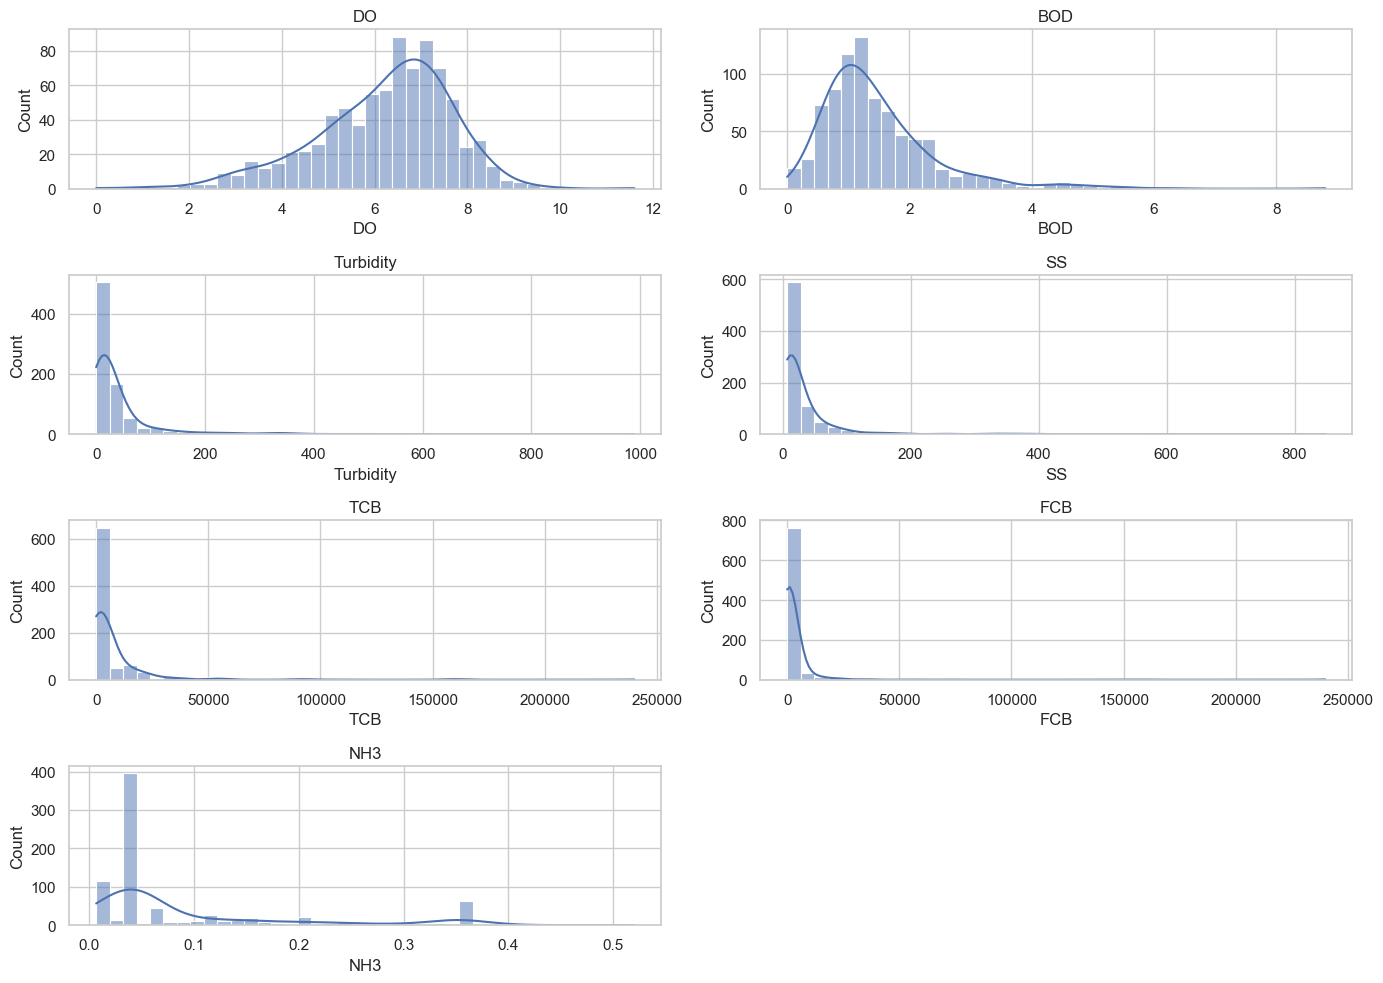

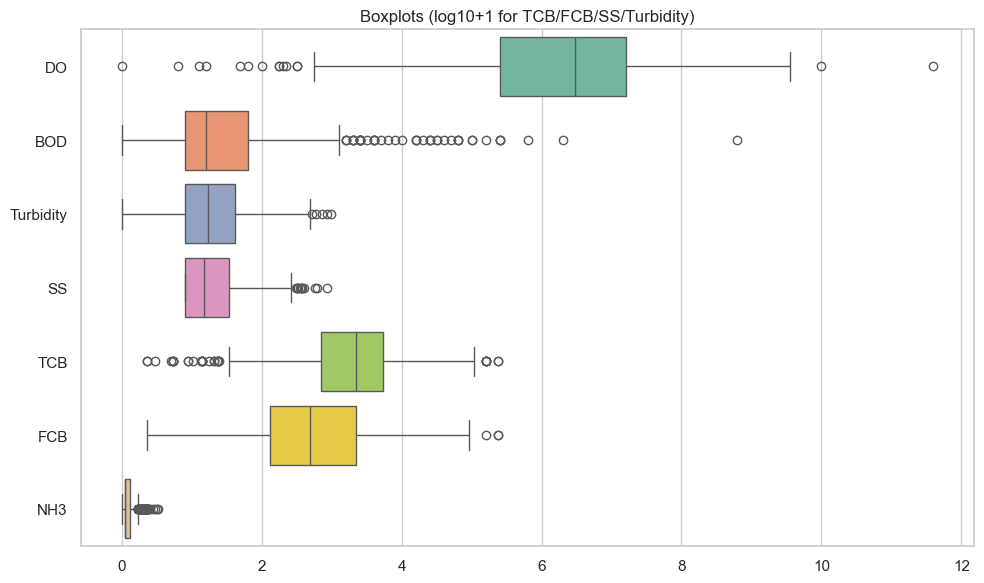

In [1]:
# Load data and plot distributions for DO, BOD, Turbidity, SS, TCB, FCB, NH3
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

csv_path = r"e:\Water Quality Research\Data\tabular_data_14\02_intermediate\wq_14_2562_2568_rs_ready.csv"
fig_dir = r"e:\Water Quality Research\Resources\figures"
os.makedirs(fig_dir, exist_ok=True)

cols_map = {
    'DO_mg_l_clean': 'DO',
    'BOD_mg_l_clean': 'BOD',
    'turbidity_NTU_clean': 'Turbidity',
    'SS_mg_l_clean': 'SS',
    'TCB_MPN_100ml_clean': 'TCB',
    'FCB_MPN_100ml_clean': 'FCB',
    'NH3_N_mg_l_clean': 'NH3',
}

print('Reading', csv_path)
df = pd.read_csv(csv_path, low_memory=False)

# Keep only requested columns and coerce to numeric
df_sel = df[[k for k in cols_map.keys() if k in df.columns]].rename(columns=cols_map)
df_sel = df_sel.apply(pd.to_numeric, errors='coerce')

# Summary
print(df_sel.describe())

# Histograms
plt.figure(figsize=(14,10))
for i, col in enumerate(df_sel.columns, start=1):
    plt.subplot(4,2,i)
    sns.histplot(df_sel[col].dropna(), bins=40, kde=True)
    plt.title(col)

plt.tight_layout()
hist_path = os.path.join(fig_dir, 'wq_distributions_hist.png')
plt.savefig(hist_path, dpi=150)
print('Saved histogram to', hist_path)

# Boxplots (log scale for some highly skewed parameters)
plt.figure(figsize=(10,6))
# Use a copy and apply log10+1 for heavy-tailed parameters for visualization
df_box = df_sel.copy()
for c in ['TCB','FCB','SS','Turbidity']:
    if c in df_box.columns:
        df_box[c] = pd.to_numeric(df_box[c], errors='coerce')
        df_box[c] = (df_box[c].clip(lower=0)).apply(lambda x: np.log10(x+1) if pd.notna(x) else x)

sns.boxplot(data=df_box, orient='h', palette='Set2')
plt.title('Boxplots (log10+1 for TCB/FCB/SS/Turbidity)')
plt.tight_layout()
box_path = os.path.join(fig_dir, 'wq_distributions_box.png')
plt.savefig(box_path, dpi=150)
print('Saved boxplots to', box_path)